# Goal:
Assess the viability of SARIMA pipeline

In [3]:
# Core
import numpy as np
import pandas as pd

# Visualization (optional but useful for diagnostics)
import matplotlib.pyplot as plt
import seaborn as sns

# Data prep and evaluation
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Supervised regression models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor

# XGBoost
from xgboost import XGBRegressor

In [60]:
# conduct k-NN to find 5 nearest neighbors

train_df= pd.read_csv("5411_train_temporal_with_costs.csv")
val_df= pd.read_csv("5411_validate_temporal_with_costs.csv")
test_df= pd.read_csv("5411_test_temporal_with_costs.csv")

all_df = pd.concat([train_df, val_df, test_df], ignore_index=True)  

train_df.info()

all_df.info()



<class 'pandas.DataFrame'>
RangeIndex: 167323 entries, 0 to 167322
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   transaction_id   167323 non-null  int64  
 1   date             167323 non-null  str    
 2   amount           167323 non-null  float64
 3   use_chip         167323 non-null  str    
 4   merchant_id      167323 non-null  int64  
 5   mcc              167323 non-null  float64
 6   errors           1888 non-null    str    
 7   card_brand       167323 non-null  str    
 8   card_type        167323 non-null  str    
 9   mcc_description  167323 non-null  str    
 10  cost_type_ID     153992 non-null  float64
 11  proc_cost        153992 non-null  float64
dtypes: float64(4), int64(2), str(6)
memory usage: 27.5 MB
<class 'pandas.DataFrame'>
RangeIndex: 473012 entries, 0 to 473011
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------

In [61]:
# remove error cost_type_ID

all_df = all_df[all_df['cost_type_ID'] != 'NaN']
train_df = train_df[train_df['cost_type_ID'] != 'NaN']
val_df = val_df[val_df['cost_type_ID'] != 'NaN']
test_df = test_df[test_df['cost_type_ID'] != 'NaN']

train_df = train_df.dropna(subset=['cost_type_ID'])
val_df = val_df.dropna(subset=['cost_type_ID'])
test_df = test_df.dropna(subset=['cost_type_ID'])
all_df = all_df.dropna(subset=['cost_type_ID'])

# keep only rows with no recorded errors in the training set
train_df = train_df[train_df['errors'].isna()].copy()
val_df = val_df[val_df['errors'].isna()].copy()
test_df = test_df[test_df['errors'].isna()].copy()
all_df = all_df[all_df['errors'].isna()].copy()

train_df.info()

<class 'pandas.DataFrame'>
Index: 152241 entries, 0 to 167322
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   transaction_id   152241 non-null  int64  
 1   date             152241 non-null  str    
 2   amount           152241 non-null  float64
 3   use_chip         152241 non-null  str    
 4   merchant_id      152241 non-null  int64  
 5   mcc              152241 non-null  float64
 6   errors           0 non-null       str    
 7   card_brand       152241 non-null  str    
 8   card_type        152241 non-null  str    
 9   mcc_description  152241 non-null  str    
 10  cost_type_ID     152241 non-null  float64
 11  proc_cost        152241 non-null  float64
dtypes: float64(4), int64(2), str(6)
memory usage: 26.3 MB


In [89]:
# make weekly features by merchant

COST_TYPE_IDS = list(range(1, 62))


def build_weekly_merchant_features(df, split_year):
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    df = df[df['date'].dt.year == split_year].copy()

    # Force an exact 52-week calendar inside each split year.
    year_start = pd.Timestamp(f'{split_year}-01-01')
    day_offset = (df['date'] - year_start).dt.days
    df['week_of_year'] = np.clip((day_offset // 7) + 1, 1, 52).astype(int)

    df['cost_type_ID'] = pd.to_numeric(df['cost_type_ID'], errors='coerce').astype('Int64')
    df['txn_cost_percent'] = np.where(df['amount'] != 0, df['proc_cost'] / df['amount'], np.nan)

    weekly_summary = (
        df.groupby(['merchant_id', 'week_of_year'], as_index=False)
        .agg(
            total_proc_cost=('proc_cost', 'sum'),
            total_amount=('amount', 'sum'),
            total_transactions=('transaction_id', 'count'),
            cost_percent_stdev=('txn_cost_percent', 'std'),
        )
    )

    weekly_summary['cost_percent'] = np.where(
        weekly_summary['total_amount'] != 0,
        weekly_summary['total_proc_cost'] / weekly_summary['total_amount'],
        np.nan,
    )
    weekly_summary = weekly_summary.drop(columns=['total_proc_cost', 'total_amount'])

    cost_type_counts = (
        df.dropna(subset=['cost_type_ID'])
        .groupby(['merchant_id', 'week_of_year', 'cost_type_ID'])['transaction_id']
        .count()
        .unstack(fill_value=0)
        .reindex(columns=COST_TYPE_IDS, fill_value=0)
    )

    cost_type_pct = cost_type_counts.div(cost_type_counts.sum(axis=1), axis=0).fillna(0)
    cost_type_pct.columns = [f'pct_cost_type_{cost_type_id}' for cost_type_id in cost_type_pct.columns]
    cost_type_pct = cost_type_pct.reset_index()

    weekly_features = weekly_summary.merge(
        cost_type_pct,
        on=['merchant_id', 'week_of_year'],
        how='left',
    )

    merchants = pd.Index(sorted(df['merchant_id'].dropna().unique()), name='merchant_id')
    weeks = pd.Index(range(1, 53), name='week_of_year')
    full_grid = pd.MultiIndex.from_product([merchants, weeks], names=['merchant_id', 'week_of_year']).to_frame(index=False)

    weekly_features = full_grid.merge(
        weekly_features,
        on=['merchant_id', 'week_of_year'],
        how='left',
    )

    pct_cols = [f'pct_cost_type_{cost_type_id}' for cost_type_id in COST_TYPE_IDS]
    weekly_features[pct_cols] = weekly_features[pct_cols].fillna(0.0)
    weekly_features['total_transactions'] = weekly_features['total_transactions'].fillna(0).astype(int)
    weekly_features['split_year'] = split_year

    ordered_cols = [
        'split_year',
        'week_of_year',
        'merchant_id',
        'cost_percent',
        *pct_cols,
        'total_transactions',
        'cost_percent_stdev',
    ]
    weekly_features = weekly_features[ordered_cols].sort_values(['merchant_id', 'week_of_year']).reset_index(drop=True)

    return weekly_features


weekly_train_features = build_weekly_merchant_features(train_df, 2017)
weekly_validate_features = build_weekly_merchant_features(val_df, 2018)
weekly_test_features = build_weekly_merchant_features(test_df, 2019)

print('Train weekly feature shape:', weekly_train_features.shape)
print('Validate weekly feature shape:', weekly_validate_features.shape)
print('Test weekly feature shape:', weekly_test_features.shape)

weekly_train_features.head()

Train weekly feature shape: (144248, 67)
Validate weekly feature shape: (143156, 67)
Test weekly feature shape: (132704, 67)


,split_year,week_of_year,merchant_id,cost_percent,pct_cost_type_1,pct_cost_type_2,pct_cost_type_3,pct_cost_type_4,pct_cost_type_5,pct_cost_type_6,...,pct_cost_type_54,pct_cost_type_55,pct_cost_type_56,pct_cost_type_57,pct_cost_type_58,pct_cost_type_59,pct_cost_type_60,pct_cost_type_61,total_transactions,cost_percent_stdev
0,2017,1,34,NaN,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN
1,2017,2,34,NaN,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN
2,2017,3,34,NaN,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN
3,2017,4,34,NaN,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN
4,2017,5,34,NaN,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN


In [98]:
# build continuous weekly all_df and isolate new-merchant set for leakage-safe KNN testing

all_weekly_df = pd.concat(
    [weekly_train_features, weekly_validate_features, weekly_test_features],
    ignore_index=True,
).sort_values(['split_year', 'merchant_id', 'week_of_year']).reset_index(drop=True)

# Candidate "new merchants" for Jan 2019 query.
historical_active_2017_2018 = set(
    pd.concat([weekly_train_features, weekly_validate_features], ignore_index=True)
    .loc[lambda d: d['total_transactions'] > 0, 'merchant_id']
    .unique()
)
historical_active_2017 = set(
    weekly_train_features.loc[weekly_train_features['total_transactions'] > 0, 'merchant_id'].unique()
)

jan2019_features = weekly_test_features[
    weekly_test_features['week_of_year'].between(1, 4)
].copy()

jan2019_activity = (
    jan2019_features.assign(active_week=lambda d: d['total_transactions'] > 0)
    .groupby('merchant_id', as_index=False)
    .agg(
        jan_active_weeks=('active_week', 'sum'),
        jan_total_txn=('total_transactions', 'sum'),
    )
)

primary_ids = sorted(
    jan2019_activity.loc[
        (jan2019_activity['jan_active_weeks'] == 4)
        & (~jan2019_activity['merchant_id'].isin(historical_active_2017_2018)),
        'merchant_id',
    ].tolist()
)

if len(primary_ids) > 0:
    new_merchant_ids = primary_ids
    selection_rule = 'primary: no 2017-2018 activity'
else:
    fallback_ids = sorted(
        jan2019_activity.loc[
            (jan2019_activity['jan_active_weeks'] == 4)
            & (~jan2019_activity['merchant_id'].isin(historical_active_2017)),
            'merchant_id',
        ].tolist()
    )

    if len(fallback_ids) > 0:
        new_merchant_ids = fallback_ids
        selection_rule = 'fallback: no 2017 activity'
    else:
        # Final fallback: choose the strongest Jan 2019 merchant with full 4-week activity.
        top_candidate = (
            jan2019_activity[jan2019_activity['jan_active_weeks'] == 4]
            .sort_values('jan_total_txn', ascending=False)
            .head(1)
        )
        new_merchant_ids = top_candidate['merchant_id'].tolist()
        selection_rule = 'fallback: top Jan-2019 activity among full 4-week merchants'

new_merchant_jan2019_df = jan2019_features[
    jan2019_features['merchant_id'].isin(new_merchant_ids)
].copy()

# Leakage-safe model pool: keep only 2017-2018 history and remove isolated merchants.
all_df_model_pool = all_weekly_df[
    (all_weekly_df['split_year'].isin([2017, 2018]))
    & (~all_weekly_df['merchant_id'].isin(new_merchant_ids))
].copy()

print('all_weekly_df shape:', all_weekly_df.shape)
print('New-merchant selection rule:', selection_rule)
print('Number of isolated new merchants (Jan 2019):', len(new_merchant_ids))
print('new_merchant_jan2019_df shape:', new_merchant_jan2019_df.shape)
print('all_df_model_pool shape (2017-2018 only):', all_df_model_pool.shape)

if len(new_merchant_ids) > 0:
    print('Example isolated merchant IDs:', new_merchant_ids[:10])

new_merchant_jan2019_df.head()

all_weekly_df shape: (420108, 67)
New-merchant selection rule: fallback: top Jan-2019 activity among full 4-week merchants
Number of isolated new merchants (Jan 2019): 1
new_merchant_jan2019_df shape: (4, 67)
all_df_model_pool shape (2017-2018 only): (287300, 67)
Example isolated merchant IDs: [50783]


,split_year,week_of_year,merchant_id,cost_percent,pct_cost_type_1,pct_cost_type_2,pct_cost_type_3,pct_cost_type_4,pct_cost_type_5,pct_cost_type_6,...,pct_cost_type_54,pct_cost_type_55,pct_cost_type_56,pct_cost_type_57,pct_cost_type_58,pct_cost_type_59,pct_cost_type_60,pct_cost_type_61,total_transactions,cost_percent_stdev
67600,2019,1,50783,0.018815,0.013436,0.072937,0.000000,0.013436,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,521,0.093879
67601,2019,2,50783,0.017558,0.010949,0.065693,0.001825,0.018248,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,548,0.066728
67602,2019,3,50783,0.018912,0.017442,0.073643,0.005814,0.015504,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,516,0.075561
67603,2019,4,50783,0.017383,0.001873,0.082397,0.003745,0.020599,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,534,0.083768


In [99]:
# fit z-score scaler on model pool and apply to new merchant set

id_cols = ['split_year', 'week_of_year', 'merchant_id']
feature_cols = [col for col in all_df_model_pool.columns if col not in id_cols]

# Fill missing values consistently before scaling.
pool_for_scaling = all_df_model_pool[feature_cols].fillna(0.0)
new_for_scaling = new_merchant_jan2019_df[feature_cols].fillna(0.0)

z_scaler = StandardScaler()
z_scaler.fit(pool_for_scaling)

pool_scaled_values = z_scaler.transform(pool_for_scaling)

all_df_model_pool_z = all_df_model_pool[id_cols].copy()
all_df_model_pool_z[feature_cols] = pool_scaled_values

if len(new_for_scaling) > 0:
    new_scaled_values = z_scaler.transform(new_for_scaling)
    new_merchant_jan2019_z = new_merchant_jan2019_df[id_cols].copy()
    new_merchant_jan2019_z[feature_cols] = new_scaled_values
else:
    new_merchant_jan2019_z = new_merchant_jan2019_df[id_cols + feature_cols].copy()

print('Feature columns standardized:', len(feature_cols))
print('Pool z-scored shape:', all_df_model_pool_z.shape)
print('New merchant z-scored shape:', new_merchant_jan2019_z.shape)
print('')

# quick sanity check on first few standardized pool features
sanity_cols = feature_cols[:5]
print('Pool z-score means (first 5 features, should be ~0):')
print(all_df_model_pool_z[sanity_cols].mean().round(4))
print('\nPool z-score std (first 5 features, should be ~1):')
print(all_df_model_pool_z[sanity_cols].std(ddof=0).round(4))

new_merchant_jan2019_z.head()

Feature columns standardized: 64
Pool z-scored shape: (287300, 67)
New merchant z-scored shape: (4, 67)

Pool z-score means (first 5 features, should be ~0):
cost_percent      -0.0
pct_cost_type_1    0.0
pct_cost_type_2    0.0
pct_cost_type_3    0.0
pct_cost_type_4    0.0
dtype: float64

Pool z-score std (first 5 features, should be ~1):
cost_percent       1.0
pct_cost_type_1    1.0
pct_cost_type_2    1.0
pct_cost_type_3    1.0
pct_cost_type_4    1.0
dtype: float64


,split_year,week_of_year,merchant_id,cost_percent,pct_cost_type_1,pct_cost_type_2,pct_cost_type_3,pct_cost_type_4,pct_cost_type_5,pct_cost_type_6,...,pct_cost_type_54,pct_cost_type_55,pct_cost_type_56,pct_cost_type_57,pct_cost_type_58,pct_cost_type_59,pct_cost_type_60,pct_cost_type_61,total_transactions,cost_percent_stdev
67600,2019,1,50783,0.119517,0.273649,0.466922,-0.044907,0.129257,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,50.106383,1.515253
67601,2019,2,50783,0.102748,0.212535,0.404706,0.019451,0.207036,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,52.707374,1.053751
67602,2019,3,50783,0.120808,0.372102,0.472993,0.160143,0.162683,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49.624718,1.203882
67603,2019,4,50783,0.100423,-0.010517,0.548183,0.087185,0.245034,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,51.358712,1.343387


In [100]:
# run k-NN with k=5 using full Jan (weeks 1-4) trajectories (scale + trend)

from sklearn.neighbors import NearestNeighbors

K = 5
TARGET_WEEKS = [1, 2, 3, 4]

# Use the same features that were z-scored; keep an explicit order.
trajectory_feature_cols = feature_cols


def build_weekly_trajectory_matrix(df, merchant_col='merchant_id'):
    """
    Build one row per merchant by flattening week-by-week features:
    [week1_feat1..featN, week2_feat1..featN, week3..., week4...]
    This makes k-NN compare the full 4-week shape, not just an average.
    """
    tmp = df[df['week_of_year'].isin(TARGET_WEEKS)].copy()
    tmp = tmp[[merchant_col, 'week_of_year'] + trajectory_feature_cols]

    tmp = (
        tmp.groupby([merchant_col, 'week_of_year'], as_index=False)[trajectory_feature_cols]
        .mean()
    )

    merchants = sorted(tmp[merchant_col].unique())
    blocks = []

    for wk in TARGET_WEEKS:
        wk_df = (
            tmp[tmp['week_of_year'] == wk]
            .set_index(merchant_col)[trajectory_feature_cols]
            .reindex(merchants)
            .fillna(0.0)
        )
        wk_df.columns = [f'w{wk}_{c}' for c in trajectory_feature_cols]
        blocks.append(wk_df)

    traj_df = pd.concat(blocks, axis=1)
    traj_df.index.name = merchant_col
    traj_df = traj_df.reset_index()
    return traj_df


# Pool trajectories are from 2017-2018 history only; query is Jan 2019 new merchants.
pool_traj_df = build_weekly_trajectory_matrix(all_df_model_pool_z)
new_traj_df = build_weekly_trajectory_matrix(new_merchant_jan2019_z)

X_pool = pool_traj_df.drop(columns=['merchant_id']).values
X_query = new_traj_df.drop(columns=['merchant_id']).values
pool_ids = pool_traj_df['merchant_id'].values
query_ids = new_traj_df['merchant_id'].values

knn = NearestNeighbors(n_neighbors=K, metric='euclidean')
knn.fit(X_pool)

distances, indices = knn.kneighbors(X_query)

knn_rows = []
for i, query_merchant_id in enumerate(query_ids):
    for rank, (dist, idx) in enumerate(zip(distances[i], indices[i]), start=1):
        knn_rows.append(
            {
                'query_merchant_id': int(query_merchant_id),
                'neighbor_rank': rank,
                'neighbor_merchant_id': int(pool_ids[idx]),
                'trajectory_distance': float(dist),
            }
        )

knn_results_df = (
    pd.DataFrame(knn_rows)
    .sort_values(['query_merchant_id', 'neighbor_rank'])
    .reset_index(drop=True)
)

print('New merchants queried:', len(query_ids))
print('Pool merchants searched:', len(pool_ids))
print('k:', K)
print('Trajectory vector length:', X_pool.shape[1], '(4 weeks x', len(trajectory_feature_cols), 'features)')
print('')

display(knn_results_df)

first_query_id = int(knn_results_df['query_merchant_id'].iloc[0])
print(f'Nearest neighbors for query merchant {first_query_id}:')
display(knn_results_df[knn_results_df['query_merchant_id'] == first_query_id])

New merchants queried: 1
Pool merchants searched: 3881
k: 5
Trajectory vector length: 256 (4 weeks x 64 features)



,query_merchant_id,neighbor_rank,neighbor_merchant_id,trajectory_distance
0,50783,1,75781,10.150276
1,50783,2,46284,77.240113
2,50783,3,98374,79.235004
3,50783,4,83229,92.346719
4,50783,5,2177,92.395786


Nearest neighbors for query merchant 50783:


,query_merchant_id,neighbor_rank,neighbor_merchant_id,trajectory_distance
0,50783,1,75781,10.150276
1,50783,2,46284,77.240113
2,50783,3,98374,79.235004
3,50783,4,83229,92.346719
4,50783,5,2177,92.395786


In [101]:
# weighted-distance k-NN variant (emphasize scale/trend features)

K = 5

traj_feature_names = pool_traj_df.drop(columns=['merchant_id']).columns.tolist()

# Base weight for all features.
feature_weight_map = {name: 1.0 for name in traj_feature_names}

# Upweight trajectory dimensions that capture overall scale and trend.
for fname in traj_feature_names:
    if fname.endswith('_cost_percent'):
        feature_weight_map[fname] = 3.0
    elif fname.endswith('_total_transactions'):
        feature_weight_map[fname] = 2.5
    elif fname.endswith('_cost_percent_stdev'):
        feature_weight_map[fname] = 2.0

weight_vector = np.array([feature_weight_map[name] for name in traj_feature_names])

X_pool = pool_traj_df.drop(columns=['merchant_id']).values
X_query = new_traj_df.drop(columns=['merchant_id']).values
pool_ids = pool_traj_df['merchant_id'].values
query_ids = new_traj_df['merchant_id'].values

weighted_knn_rows = []
for q_idx, q_id in enumerate(query_ids):
    diff = X_pool - X_query[q_idx]
    weighted_sq = (diff ** 2) * weight_vector
    weighted_dist = np.sqrt(weighted_sq.sum(axis=1))

    top_idx = np.argsort(weighted_dist)[:K]
    for rank, idx in enumerate(top_idx, start=1):
        weighted_knn_rows.append(
            {
                'query_merchant_id': int(q_id),
                'neighbor_rank': rank,
                'neighbor_merchant_id': int(pool_ids[idx]),
                'weighted_trajectory_distance': float(weighted_dist[idx]),
            }
        )

weighted_knn_results_df = (
    pd.DataFrame(weighted_knn_rows)
    .sort_values(['query_merchant_id', 'neighbor_rank'])
    .reset_index(drop=True)
)

print('Weighted k-NN complete')
print('Weighting scheme: cost_percent=3.0, total_transactions=2.5, cost_percent_stdev=2.0, others=1.0')
print('k:', K)
print('')

display(weighted_knn_results_df)

first_query_id = int(weighted_knn_results_df['query_merchant_id'].iloc[0])
print(f'Weighted nearest neighbors for query merchant {first_query_id}:')
display(weighted_knn_results_df[weighted_knn_results_df['query_merchant_id'] == first_query_id])

# Quick side-by-side with unweighted neighbors.
comparison_df = (
    knn_results_df[['query_merchant_id', 'neighbor_rank', 'neighbor_merchant_id', 'trajectory_distance']]
    .merge(
        weighted_knn_results_df,
        on=['query_merchant_id', 'neighbor_rank'],
        suffixes=('_unweighted', '_weighted'),
    )
)

print('Unweighted vs weighted comparison by rank:')
display(comparison_df)

Weighted k-NN complete
Weighting scheme: cost_percent=3.0, total_transactions=2.5, cost_percent_stdev=2.0, others=1.0
k: 5



,query_merchant_id,neighbor_rank,neighbor_merchant_id,weighted_trajectory_distance
0,50783,1,75781,14.878903
1,50783,2,46284,122.097032
2,50783,3,98374,125.259967
3,50783,4,83229,145.960083
4,50783,5,2177,146.037542


Weighted nearest neighbors for query merchant 50783:


,query_merchant_id,neighbor_rank,neighbor_merchant_id,weighted_trajectory_distance
0,50783,1,75781,14.878903
1,50783,2,46284,122.097032
2,50783,3,98374,125.259967
3,50783,4,83229,145.960083
4,50783,5,2177,146.037542


Unweighted vs weighted comparison by rank:


,query_merchant_id,neighbor_rank,neighbor_merchant_id_unweighted,trajectory_distance,neighbor_merchant_id_weighted,weighted_trajectory_distance
0,50783,1,75781,10.150276,75781,14.878903
1,50783,2,46284,77.240113,46284,122.097032
2,50783,3,98374,79.235004,98374,125.259967
3,50783,4,83229,92.346719,83229,145.960083
4,50783,5,2177,92.395786,2177,146.037542


In [102]:
# summarize engineered features and key Jan trajectories

pct_cols = [c for c in feature_cols if c.startswith('pct_cost_type_')]
core_cols = [c for c in ['cost_percent', 'total_transactions', 'cost_percent_stdev'] if c in feature_cols]
other_cols = [c for c in feature_cols if c not in pct_cols + core_cols]

feature_summary_df = pd.DataFrame(
    {
        'feature_group': ['core', 'cost_type_mix', 'other'],
        'count': [len(core_cols), len(pct_cols), len(other_cols)],
        'columns': [', '.join(core_cols), f'{pct_cols[0]} ... {pct_cols[-1]}' if pct_cols else '', ', '.join(other_cols) if other_cols else '-'],
    }
)

print('Feature Set Summary')
print('Total engineered features:', len(feature_cols))
display(feature_summary_df)

# Summarize key weekly features for query merchant (Jan 2019) and top 5 weighted neighbors (Jan 2018).
query_id = int(weighted_knn_results_df['query_merchant_id'].iloc[0])
neighbor_ids = weighted_knn_results_df.loc[
    weighted_knn_results_df['query_merchant_id'] == query_id,
    'neighbor_merchant_id',
].tolist()

query_trace = all_weekly_df[
    (all_weekly_df['merchant_id'] == query_id)
    & (all_weekly_df['split_year'] == 2019)
    & (all_weekly_df['week_of_year'].between(1, 4))
][['merchant_id', 'split_year', 'week_of_year', 'cost_percent', 'total_transactions', 'cost_percent_stdev']].copy()
query_trace['merchant_role'] = 'query_jan2019'

neighbor_trace = all_weekly_df[
    (all_weekly_df['merchant_id'].isin(neighbor_ids))
    & (all_weekly_df['split_year'] == 2018)
    & (all_weekly_df['week_of_year'].between(1, 4))
][['merchant_id', 'split_year', 'week_of_year', 'cost_percent', 'total_transactions', 'cost_percent_stdev']].copy()

neighbor_label_map = {mid: f'neighbor_{i+1}_jan2018' for i, mid in enumerate(neighbor_ids)}
neighbor_trace['merchant_role'] = neighbor_trace['merchant_id'].map(neighbor_label_map)

jan_trace = pd.concat([query_trace, neighbor_trace], ignore_index=True)
jan_trace = jan_trace.sort_values(['merchant_role', 'week_of_year']).reset_index(drop=True)

print('')
print('Trajectory snapshot: query Jan 2019 vs neighbors Jan 2018:')
display(jan_trace)

Feature Set Summary
Total engineered features: 64


,feature_group,count,columns
0,core,3,"cost_percent, total_transactions, cost_percent..."
1,cost_type_mix,61,pct_cost_type_1 ... pct_cost_type_61
2,other,0,-



Trajectory snapshot: query Jan 2019 vs neighbors Jan 2018:


,merchant_id,split_year,week_of_year,cost_percent,total_transactions,cost_percent_stdev,merchant_role
0,75781,2018,1,0.017990,517,0.086551,neighbor_1_jan2018
1,75781,2018,2,0.018329,498,0.348455,neighbor_1_jan2018
2,75781,2018,3,0.020037,486,0.527190,neighbor_1_jan2018
3,75781,2018,4,0.017783,550,0.336085,neighbor_1_jan2018
4,46284,2018,1,0.019224,136,0.044900,neighbor_2_jan2018
5,46284,2018,2,0.018711,121,0.326441,neighbor_2_jan2018
6,46284,2018,3,0.018689,129,0.035150,neighbor_2_jan2018
7,46284,2018,4,0.016595,129,0.032065,neighbor_2_jan2018
8,98374,2018,1,0.021683,144,0.141770,neighbor_3_jan2018
9,98374,2018,2,0.018023,112,0.077934,neighbor_3_jan2018


In [103]:
# build composite merchant from top-5 unweighted neighbors (2017-2018 history only)

EPS = 1e-9

query_id = int(knn_results_df['query_merchant_id'].iloc[0])
top5_unweighted = knn_results_df[
    knn_results_df['query_merchant_id'] == query_id
].sort_values('neighbor_rank').head(5).copy()

# Inverse-distance weighting from unweighted trajectory distances.
top5_unweighted['raw_weight'] = 1.0 / (top5_unweighted['trajectory_distance'] + EPS)
top5_unweighted['neighbor_weight'] = top5_unweighted['raw_weight'] / top5_unweighted['raw_weight'].sum()

neighbor_weights = top5_unweighted[['neighbor_merchant_id', 'neighbor_weight']].copy()
neighbor_weights = neighbor_weights.rename(columns={'neighbor_merchant_id': 'merchant_id'})

# Keep 2017-2018 historical weekly timeline (through Dec 2018).
history_mask = all_weekly_df['split_year'].isin([2017, 2018])

neighbor_history = all_weekly_df[
    history_mask & all_weekly_df['merchant_id'].isin(neighbor_weights['merchant_id'])
].copy()

neighbor_history = neighbor_history.merge(neighbor_weights, on='merchant_id', how='left')

# Weighted aggregate across neighbors for each week.
composite_merchant_df = (
    neighbor_history
    .assign(**{col: neighbor_history[col] * neighbor_history['neighbor_weight'] for col in feature_cols})
    .groupby(['split_year', 'week_of_year'], as_index=False)[feature_cols]
    .sum()
    .sort_values(['split_year', 'week_of_year'])
    .reset_index(drop=True)
)

composite_merchant_df.insert(0, 'merchant_id', -1)
composite_merchant_df.insert(0, 'merchant_role', 'composite_from_top5_unweighted')

print('Query merchant (Jan 2019):', query_id)
print('Top-5 neighbors used:', top5_unweighted['neighbor_merchant_id'].tolist())
print('Composite history shape:', composite_merchant_df.shape)
print('')
print('Neighbor weights (inverse-distance normalized):')
display(top5_unweighted[['neighbor_rank', 'neighbor_merchant_id', 'trajectory_distance', 'neighbor_weight']])

print('Composite merchant timeline preview (2017-2018 only):')
display(composite_merchant_df.head(12))

print('Composite merchant final weeks (Dec 2018):')
display(composite_merchant_df[(composite_merchant_df['split_year'] == 2018) & (composite_merchant_df['week_of_year'].between(49, 52))])

Query merchant (Jan 2019): 50783
Top-5 neighbors used: [75781, 46284, 98374, 83229, 2177]
Composite history shape: (104, 68)

Neighbor weights (inverse-distance normalized):


,neighbor_rank,neighbor_merchant_id,trajectory_distance,neighbor_weight
0,1,75781,10.150276,0.676001
1,2,46284,77.240113,0.088835
2,3,98374,79.235004,0.086598
3,4,83229,92.346719,0.074303
4,5,2177,92.395786,0.074263


Composite merchant timeline preview (2017-2018 only):


,merchant_role,merchant_id,split_year,week_of_year,cost_percent,pct_cost_type_1,pct_cost_type_2,pct_cost_type_3,pct_cost_type_4,pct_cost_type_5,...,pct_cost_type_54,pct_cost_type_55,pct_cost_type_56,pct_cost_type_57,pct_cost_type_58,pct_cost_type_59,pct_cost_type_60,pct_cost_type_61,total_transactions,cost_percent_stdev
0,composite_from_top5_unweighted,-1,2017,1,0.019032,0.009826,0.088229,0.010539,0.028317,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,350.660787,0.162818
1,composite_from_top5_unweighted,-1,2017,2,0.019016,0.006244,0.080691,0.006533,0.030590,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,361.754039,0.066929
2,composite_from_top5_unweighted,-1,2017,3,0.018013,0.015155,0.061974,0.002625,0.039329,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,376.481356,0.079886
3,composite_from_top5_unweighted,-1,2017,4,0.018648,0.006402,0.083600,0.003996,0.040581,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,385.420490,0.442929
4,composite_from_top5_unweighted,-1,2017,5,0.018298,0.009153,0.087297,0.006677,0.024847,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,378.473573,0.210152
5,composite_from_top5_unweighted,-1,2017,6,0.019231,0.007638,0.081651,0.005878,0.039363,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,387.978795,0.079316
6,composite_from_top5_unweighted,-1,2017,7,0.018072,0.013828,0.083764,0.008229,0.022086,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,364.064523,0.102204
7,composite_from_top5_unweighted,-1,2017,8,0.018357,0.013835,0.083303,0.007711,0.029515,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,360.695843,0.346357
8,composite_from_top5_unweighted,-1,2017,9,0.017666,0.010270,0.077374,0.003527,0.025765,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,363.211101,0.070392
9,composite_from_top5_unweighted,-1,2017,10,0.018832,0.007705,0.085992,0.008112,0.032422,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,363.625269,0.443044


Composite merchant final weeks (Dec 2018):


,merchant_role,merchant_id,split_year,week_of_year,cost_percent,pct_cost_type_1,pct_cost_type_2,pct_cost_type_3,pct_cost_type_4,pct_cost_type_5,...,pct_cost_type_54,pct_cost_type_55,pct_cost_type_56,pct_cost_type_57,pct_cost_type_58,pct_cost_type_59,pct_cost_type_60,pct_cost_type_61,total_transactions,cost_percent_stdev
100,composite_from_top5_unweighted,-1,2018,49,0.018616,0.015600,0.079047,0.012020,0.032947,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,380.199798,0.090243
101,composite_from_top5_unweighted,-1,2018,50,0.018203,0.014137,0.074376,0.011116,0.020591,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,385.215203,0.219564
102,composite_from_top5_unweighted,-1,2018,51,0.019412,0.008890,0.067261,0.008372,0.016799,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,361.792590,0.082361
103,composite_from_top5_unweighted,-1,2018,52,0.018395,0.011304,0.084673,0.007882,0.026152,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,419.254071,0.102232


/Users/yattmeo/Desktop/SMU/Code/404_found_us/.venv/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


Model used: SARIMA(1,1,1)x(1,1,1,52)
Training points: 104
Forecast horizon (weeks): 4
MAE:  0.000379
RMSE: 0.000490
MAPE: 2.07%



,week_of_year,actual_cost_percent,predicted_cost_percent,residual,ci_lower,ci_upper
0,1,0.018815,0.018937,-0.000122,0.017745,0.020130
1,2,0.017558,0.018206,-0.000648,0.017012,0.019399
2,3,0.018912,0.019637,-0.000725,0.018249,0.021024
3,4,0.017383,0.017405,-0.000021,0.015984,0.018826


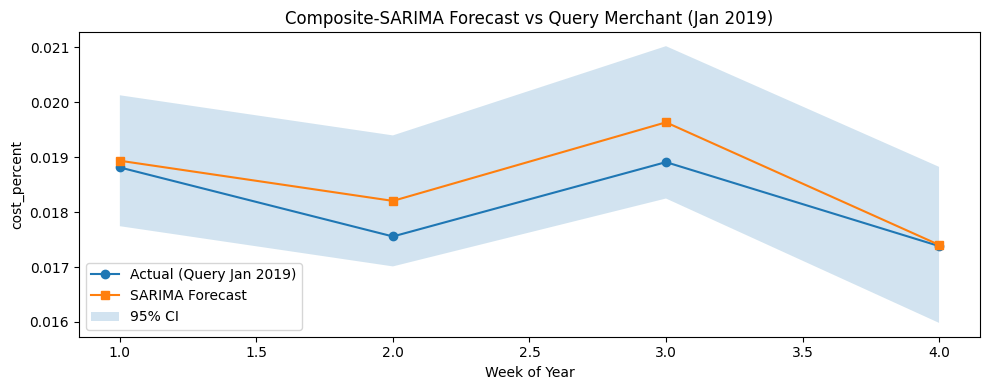

In [109]:
# establish SARIMA baseline on composite merchant

from statsmodels.tsa.statespace.sarimax import SARIMAX

# Training series: composite merchant history (2017-2018, 104 weeks)
composite_series_df = composite_merchant_df.sort_values(['split_year', 'week_of_year']).reset_index(drop=True)
y_train = composite_series_df['cost_percent'].astype(float)
y_train = y_train.interpolate(limit_direction='both').ffill().bfill()

# Query truth: Jan 2019 weeks 1-4 from isolated merchant
query_id = int(new_merchant_jan2019_df['merchant_id'].iloc[0])
y_true_df = (
    new_merchant_jan2019_df[new_merchant_jan2019_df['merchant_id'] == query_id]
    .sort_values('week_of_year')
    .loc[:, ['week_of_year', 'cost_percent']]
)
y_true = y_true_df['cost_percent'].astype(float).values

steps = len(y_true)

# Try seasonal SARIMA first, fallback to non-seasonal ARIMA if needed.
try:
    sarima_model = SARIMAX(
        y_train,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 52),
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    sarima_result = sarima_model.fit(disp=False)
    model_used = 'SARIMA(1,1,1)x(1,1,1,52)'
except Exception:
    sarima_model = SARIMAX(
        y_train,
        order=(1, 1, 1),
        seasonal_order=(0, 0, 0, 0),
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    sarima_result = sarima_model.fit(disp=False)
    model_used = 'ARIMA(1,1,1) fallback'

forecast_res = sarima_result.get_forecast(steps=steps)
y_pred = forecast_res.predicted_mean.values
ci_df = forecast_res.conf_int(alpha=0.05)

sarima_eval_df = pd.DataFrame(
    {
        'week_of_year': y_true_df['week_of_year'].values,
        'actual_cost_percent': y_true,
        'predicted_cost_percent': y_pred,
        'residual': y_true - y_pred,
    }
)

if ci_df.shape[1] >= 2:
    sarima_eval_df['ci_lower'] = ci_df.iloc[:, 0].values
    sarima_eval_df['ci_upper'] = ci_df.iloc[:, 1].values

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1e-8, None))) * 100

print('Model used:', model_used)
print('Training points:', len(y_train))
print('Forecast horizon (weeks):', steps)
print(f'MAE:  {mae:.6f}')
print(f'RMSE: {rmse:.6f}')
print(f'MAPE: {mape:.2f}%')
print('')

display(sarima_eval_df)

plt.figure(figsize=(10, 4))
plt.plot(y_true_df['week_of_year'], y_true, marker='o', label='Actual (Query Jan 2019)')
plt.plot(y_true_df['week_of_year'], y_pred, marker='s', label='SARIMA Forecast')
if 'ci_lower' in sarima_eval_df.columns and 'ci_upper' in sarima_eval_df.columns:
    plt.fill_between(
        y_true_df['week_of_year'],
        sarima_eval_df['ci_lower'],
        sarima_eval_df['ci_upper'],
        alpha=0.2,
        label='95% CI',
    )
plt.title('Composite-SARIMA Forecast vs Query Merchant (Jan 2019)')
plt.xlabel('Week of Year')
plt.ylabel('cost_percent')
plt.legend()
plt.tight_layout()
plt.show()

Linear calibration equation:
  actual ~= 0.00360533 + (0.78516677) * sarima_pred

Residual comparison:
  SARIMA MAE: 0.00037898 | RMSE: 0.00048993
  Linear-calibrated MAE: 0.00022667 | RMSE: 0.00025407
  MAE improvement: 40.19%
  RMSE improvement: 48.14%



,model,mae,rmse
0,SARIMA,0.000379,0.000490
1,SARIMA + Linear Calibration,0.000227,0.000254


,metric,baseline_sarima,calibrated,percent_improvement
0,MAE,0.000379,0.000227,40.189593
1,RMSE,0.000490,0.000254,48.142646


,week_of_year,actual_cost_percent,predicted_cost_percent,linear_calibrated_pred,sarima_residual,linear_residual
0,1,0.018815,0.018937,0.018474,-0.000122,0.000341
1,2,0.017558,0.018206,0.017900,-0.000648,-0.000342
2,3,0.018912,0.019637,0.019023,-0.000725,-0.000111
3,4,0.017383,0.017405,0.017271,-0.000021,0.000112


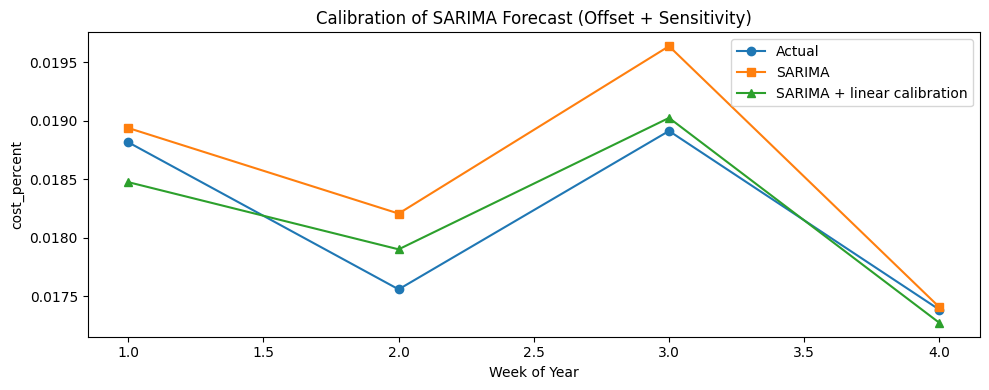

In [110]:
# linear calibration: map SARIMA forecast to actual with offset + sensitivity

# Equation form:
#   actual_t ~= offset + sensitivity * sarima_pred_t
# where offset captures level bias and sensitivity captures response scaling.

calib_df = sarima_eval_df.copy()

x = calib_df['predicted_cost_percent'].values.astype(float)
y = calib_df['actual_cost_percent'].values.astype(float)

# Least-squares fit for y = a + b*x
sensitivity, offset = np.polyfit(x, y, deg=1)

calib_df['sarima_residual'] = calib_df['actual_cost_percent'] - calib_df['predicted_cost_percent']
calib_df['linear_calibrated_pred'] = offset + sensitivity * calib_df['predicted_cost_percent']
calib_df['linear_residual'] = calib_df['actual_cost_percent'] - calib_df['linear_calibrated_pred']

# Error diagnostics for both mechanisms.
sarima_mae = mean_absolute_error(calib_df['actual_cost_percent'], calib_df['predicted_cost_percent'])
sarima_rmse = np.sqrt(mean_squared_error(calib_df['actual_cost_percent'], calib_df['predicted_cost_percent']))

linear_mae = mean_absolute_error(calib_df['actual_cost_percent'], calib_df['linear_calibrated_pred'])
linear_rmse = np.sqrt(mean_squared_error(calib_df['actual_cost_percent'], calib_df['linear_calibrated_pred']))

mae_improvement_pct = ((sarima_mae - linear_mae) / np.clip(sarima_mae, 1e-12, None)) * 100
rmse_improvement_pct = ((sarima_rmse - linear_rmse) / np.clip(sarima_rmse, 1e-12, None)) * 100

print('Linear calibration equation:')
print(f'  actual ~= {offset:.8f} + ({sensitivity:.8f}) * sarima_pred')
print('')
print('Residual comparison:')
print(f'  SARIMA MAE: {sarima_mae:.8f} | RMSE: {sarima_rmse:.8f}')
print(f'  Linear-calibrated MAE: {linear_mae:.8f} | RMSE: {linear_rmse:.8f}')
print(f'  MAE improvement: {mae_improvement_pct:.2f}%')
print(f'  RMSE improvement: {rmse_improvement_pct:.2f}%')
print('')

residual_summary_df = pd.DataFrame(
    {
        'model': ['SARIMA', 'SARIMA + Linear Calibration'],
        'mae': [sarima_mae, linear_mae],
        'rmse': [sarima_rmse, linear_rmse],
    }
)

improvement_summary_df = pd.DataFrame(
    {
        'metric': ['MAE', 'RMSE'],
        'baseline_sarima': [sarima_mae, sarima_rmse],
        'calibrated': [linear_mae, linear_rmse],
        'percent_improvement': [mae_improvement_pct, rmse_improvement_pct],
    }
)

display(residual_summary_df)
display(improvement_summary_df)
display(calib_df[['week_of_year', 'actual_cost_percent', 'predicted_cost_percent', 'linear_calibrated_pred', 'sarima_residual', 'linear_residual']])

plt.figure(figsize=(10, 4))
plt.plot(calib_df['week_of_year'], calib_df['actual_cost_percent'], marker='o', label='Actual')
plt.plot(calib_df['week_of_year'], calib_df['predicted_cost_percent'], marker='s', label='SARIMA')
plt.plot(calib_df['week_of_year'], calib_df['linear_calibrated_pred'], marker='^', label='SARIMA + linear calibration')
plt.title('Calibration of SARIMA Forecast (Offset + Sensitivity)')
plt.xlabel('Week of Year')
plt.ylabel('cost_percent')
plt.legend()
plt.tight_layout()
plt.show()

Query merchant: 50783
Evaluation window: Feb-Apr 2019 (weeks 5-16)
Weeks evaluated: 5 to 16

Continuation forecast metrics (Feb-Apr):
  SARIMA MAE: 0.00060371 | RMSE: 0.00075452
  SARIMA+LinearCal MAE: 0.00051993 | RMSE: 0.00060761
  MAE improvement: 13.88%
  RMSE improvement: 19.47%


,model,mae,rmse
0,SARIMA,0.000604,0.000755
1,SARIMA + Linear Calibration,0.000520,0.000608


,week_of_year,actual_cost_percent,sarima_pred,sarima_linear_calibrated_pred,sarima_ci_lower,sarima_ci_upper
4,5,0.017477,0.018951,0.018485,0.017430,0.020472
5,6,0.018102,0.018282,0.017960,0.016708,0.019856
6,7,0.018399,0.018122,0.017834,0.016474,0.019769
7,8,0.018427,0.017794,0.017577,0.016090,0.019499
8,9,0.017904,0.017399,0.017266,0.015631,0.019166
9,10,0.017998,0.018622,0.018226,0.016798,0.020445
10,11,0.017673,0.018138,0.017847,0.016257,0.020018
11,12,0.017868,0.019324,0.018778,0.017390,0.021258
12,13,0.018645,0.018104,0.017820,0.016116,0.020092
13,14,0.017869,0.018793,0.018361,0.016754,0.020832


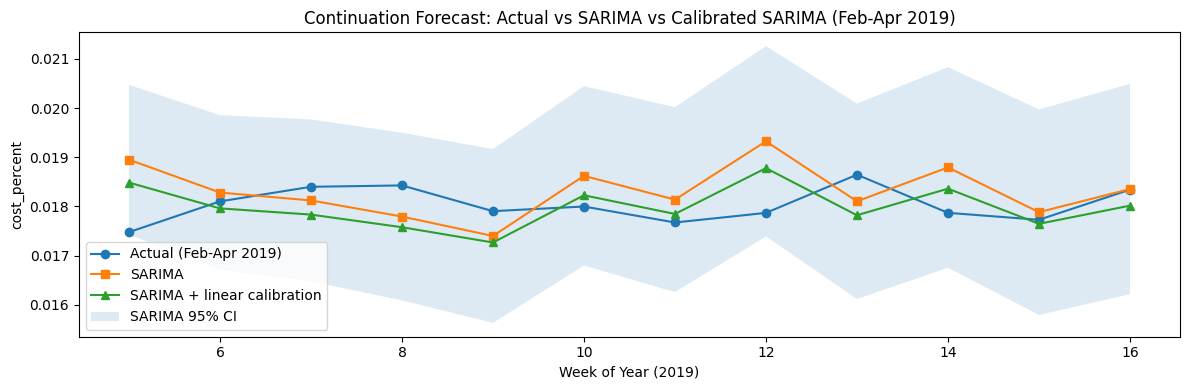

In [111]:
# out-of-sample continuation: Feb-Apr 2019 (12 weeks) using SARIMA + prior linear calibration

# We keep the same model/calibration learned earlier and extend inference forward.
# Forecast from Jan week 1 through Apr week 16, then evaluate only weeks 5-16 (Feb-Apr).

query_id = int(new_merchant_jan2019_df['merchant_id'].iloc[0])

full_2019_truth = (
    all_weekly_df[
        (all_weekly_df['merchant_id'] == query_id)
        & (all_weekly_df['split_year'] == 2019)
        & (all_weekly_df['week_of_year'].between(1, 16))
    ]
    .sort_values('week_of_year')
    .loc[:, ['week_of_year', 'cost_percent']]
    .copy()
)

# Reindex to guarantee full week coverage and preserve week labels.
full_2019_truth = (
    full_2019_truth.set_index('week_of_year')
    .reindex(range(1, 17))
    .rename_axis('week_of_year')
    .reset_index()
)

# Forecast 16 weeks ahead from the composite history endpoint (Dec 2018).
forecast_16 = sarima_result.get_forecast(steps=16)
pred_16 = forecast_16.predicted_mean.values
ci_16 = forecast_16.conf_int(alpha=0.05)

horizon_df = pd.DataFrame(
    {
        'week_of_year': np.arange(1, 17),
        'actual_cost_percent': full_2019_truth['cost_percent'].astype(float).values,
        'sarima_pred': pred_16,
    }
)

if ci_16.shape[1] >= 2:
    horizon_df['sarima_ci_lower'] = ci_16.iloc[:, 0].values
    horizon_df['sarima_ci_upper'] = ci_16.iloc[:, 1].values

# Apply previously estimated Jan calibration parameters to this new horizon.
horizon_df['sarima_linear_calibrated_pred'] = offset + sensitivity * horizon_df['sarima_pred']

# Evaluate only Feb-Apr window: weeks 5-16 (12 weeks).
feb_apr_df = horizon_df[horizon_df['week_of_year'].between(5, 16)].copy()
feb_apr_df = feb_apr_df.dropna(subset=['actual_cost_percent']).copy()

sarima_mae_feb_apr = mean_absolute_error(feb_apr_df['actual_cost_percent'], feb_apr_df['sarima_pred'])
sarima_rmse_feb_apr = np.sqrt(mean_squared_error(feb_apr_df['actual_cost_percent'], feb_apr_df['sarima_pred']))

cal_mae_feb_apr = mean_absolute_error(feb_apr_df['actual_cost_percent'], feb_apr_df['sarima_linear_calibrated_pred'])
cal_rmse_feb_apr = np.sqrt(mean_squared_error(feb_apr_df['actual_cost_percent'], feb_apr_df['sarima_linear_calibrated_pred']))

mae_improve_feb_apr = ((sarima_mae_feb_apr - cal_mae_feb_apr) / np.clip(sarima_mae_feb_apr, 1e-12, None)) * 100
rmse_improve_feb_apr = ((sarima_rmse_feb_apr - cal_rmse_feb_apr) / np.clip(sarima_rmse_feb_apr, 1e-12, None)) * 100

print(f'Query merchant: {query_id}')
print('Evaluation window: Feb-Apr 2019 (weeks 5-16)')
print(f'Weeks evaluated: {feb_apr_df["week_of_year"].min()} to {feb_apr_df["week_of_year"].max()}')
print('')
print('Continuation forecast metrics (Feb-Apr):')
print(f'  SARIMA MAE: {sarima_mae_feb_apr:.8f} | RMSE: {sarima_rmse_feb_apr:.8f}')
print(f'  SARIMA+LinearCal MAE: {cal_mae_feb_apr:.8f} | RMSE: {cal_rmse_feb_apr:.8f}')
print(f'  MAE improvement: {mae_improve_feb_apr:.2f}%')
print(f'  RMSE improvement: {rmse_improve_feb_apr:.2f}%')

feb_apr_metrics_df = pd.DataFrame(
    {
        'model': ['SARIMA', 'SARIMA + Linear Calibration'],
        'mae': [sarima_mae_feb_apr, cal_mae_feb_apr],
        'rmse': [sarima_rmse_feb_apr, cal_rmse_feb_apr],
    }
)

display(feb_apr_metrics_df)
display(
    feb_apr_df[
        [
            'week_of_year',
            'actual_cost_percent',
            'sarima_pred',
            'sarima_linear_calibrated_pred',
            'sarima_ci_lower',
            'sarima_ci_upper',
        ]
    ]
)

plt.figure(figsize=(12, 4))
plt.plot(feb_apr_df['week_of_year'], feb_apr_df['actual_cost_percent'], marker='o', label='Actual (Feb-Apr 2019)')
plt.plot(feb_apr_df['week_of_year'], feb_apr_df['sarima_pred'], marker='s', label='SARIMA')
plt.plot(
    feb_apr_df['week_of_year'],
    feb_apr_df['sarima_linear_calibrated_pred'],
    marker='^',
    label='SARIMA + linear calibration',
)
if {'sarima_ci_lower', 'sarima_ci_upper'}.issubset(feb_apr_df.columns):
    plt.fill_between(
        feb_apr_df['week_of_year'],
        feb_apr_df['sarima_ci_lower'],
        feb_apr_df['sarima_ci_upper'],
        alpha=0.15,
        label='SARIMA 95% CI',
    )
plt.title('Continuation Forecast: Actual vs SARIMA vs Calibrated SARIMA (Feb-Apr 2019)')
plt.xlabel('Week of Year (2019)')
plt.ylabel('cost_percent')
plt.legend()
plt.tight_layout()
plt.show()

MCC cross-validation setup
Candidate merchants meeting coverage rules: 543
Coverage rules: Jan non-null >= 2, Feb-Apr non-null >= 8


/Users/yattmeo/Desktop/SMU/Code/404_found_us/.venv/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/Users/yattmeo/Desktop/SMU/Code/404_found_us/.venv/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/Users/yattmeo/Desktop/SMU/Code/404_found_us/.venv/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/Users/

Processed 25/543 merchants...


/Users/yattmeo/Desktop/SMU/Code/404_found_us/.venv/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/Users/yattmeo/Desktop/SMU/Code/404_found_us/.venv/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/Users/yattmeo/Desktop/SMU/Code/404_found_us/.venv/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/Users/

Processed 50/543 merchants...


...

Processed 525/543 merchants...


/Users/yattmeo/Desktop/SMU/Code/404_found_us/.venv/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/Users/yattmeo/Desktop/SMU/Code/404_found_us/.venv/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/Users/yattmeo/Desktop/SMU/Code/404_found_us/.venv/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/Users/


Cross-validation complete
Total candidate merchants: 543
Successfully evaluated: 543
Failed/skipped: 0


,metric,value
0,Mean MAE (SARIMA),0.030483
1,Mean MAE (Calibrated),0.030636
2,Mean RMSE (SARIMA),0.041819
3,Mean RMSE (Calibrated),0.044209
4,Median MAE improvement %,24.403191
5,Median RMSE improvement %,21.023352
6,Calibration wins by MAE %,72.375691
7,Calibration wins by RMSE %,72.928177


,merchant_id,model_used,n_neighbors,n_feb_apr_points,sarima_mae,sarima_rmse,cal_mae,cal_rmse,mae_improvement_pct,rmse_improvement_pct,cv_offset,cv_sensitivity
57,9307,"SARIMA(1,1,1)x(1,1,1,52)",5,8,0.162306,0.163464,0.001697,0.002298,98.954523,98.594460,0.035833,-0.030758
142,24891,"SARIMA(1,1,1)x(1,1,1,52)",5,10,0.008322,0.009298,0.000323,0.000423,96.112959,95.449739,0.018520,-0.080848
45,7470,"SARIMA(1,1,1)x(1,1,1,52)",5,11,0.059843,0.061950,0.005979,0.010575,90.009629,82.929385,0.022878,-0.095351
368,68135,"SARIMA(1,1,1)x(1,1,1,52)",5,8,0.035170,0.036399,0.003964,0.005239,88.730266,85.607952,0.032150,-0.262293
465,86026,"SARIMA(1,1,1)x(1,1,1,52)",5,12,0.017660,0.021514,0.002045,0.002403,88.421468,88.829042,0.016276,0.034883
266,46417,"SARIMA(1,1,1)x(1,1,1,52)",5,12,0.014477,0.014906,0.001870,0.002417,87.083042,83.786025,0.019240,-0.249952
53,8702,"SARIMA(1,1,1)x(1,1,1,52)",5,8,0.015120,0.015800,0.001987,0.002491,86.857189,84.234965,0.019611,-0.194387
10,2177,"SARIMA(1,1,1)x(1,1,1,52)",5,12,0.010201,0.010799,0.001468,0.001787,85.604028,83.453516,0.015466,0.149371
168,28762,"SARIMA(1,1,1)x(1,1,1,52)",5,8,0.061064,0.061462,0.009150,0.010822,85.016436,82.392850,0.018509,-0.330514
359,65066,"SARIMA(1,1,1)x(1,1,1,52)",5,8,0.043130,0.043972,0.006487,0.008104,84.959194,81.570139,-0.003486,0.281782


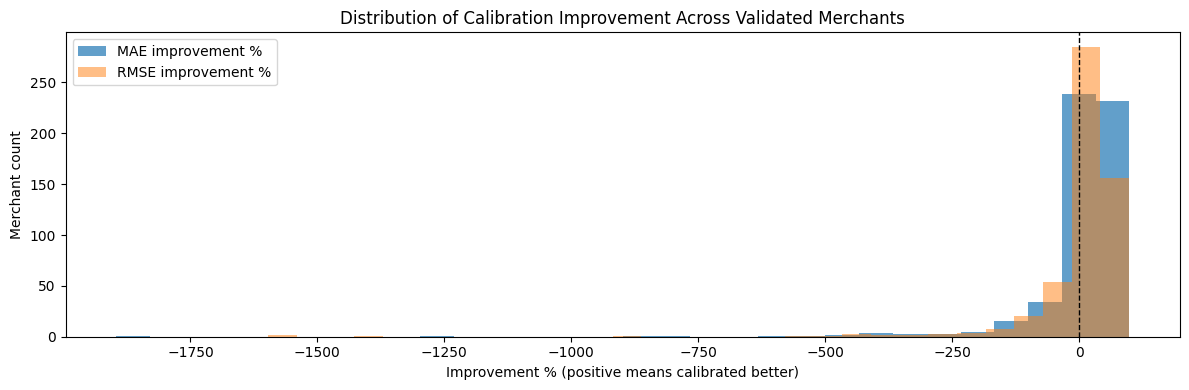

In [112]:
# cross-validation across merchants (MCC-wide) with leakage-safe leave-one-merchant-out pools

from sklearn.linear_model import LinearRegression

# Coverage rules for merchant-level validation.
MIN_JAN_NON_NULL = 2          # need enough Jan points to fit calibration
MIN_FEB_APR_NON_NULL = 8      # need enough Feb-Apr points for stable evaluation
CV_TARGET_WEEKS = [1, 2, 3, 4]
CV_FORECAST_WEEKS = list(range(1, 17))  # Jan-Apr
CV_EVAL_WEEKS = list(range(5, 17))      # Feb-Apr
CV_K = 5
CV_EPS = 1e-9

# Candidates from 2019 merchant-week panel.
test_2019_1_16 = weekly_test_features[weekly_test_features['week_of_year'].between(1, 16)].copy()
merchant_coverage = (
    test_2019_1_16.assign(
        jan_non_null=lambda d: np.where(d['week_of_year'].between(1, 4), d['cost_percent'].notna(), False),
        feb_apr_non_null=lambda d: np.where(d['week_of_year'].between(5, 16), d['cost_percent'].notna(), False),
    )
    .groupby('merchant_id', as_index=False)
    .agg(
        jan_non_null=('jan_non_null', 'sum'),
        feb_apr_non_null=('feb_apr_non_null', 'sum'),
    )
)

candidate_merchants = merchant_coverage.loc[
    (merchant_coverage['jan_non_null'] >= MIN_JAN_NON_NULL)
    & (merchant_coverage['feb_apr_non_null'] >= MIN_FEB_APR_NON_NULL),
    'merchant_id',
]
candidate_merchants = sorted(candidate_merchants.tolist())

print('MCC cross-validation setup')
print('Candidate merchants meeting coverage rules:', len(candidate_merchants))
print(f'Coverage rules: Jan non-null >= {MIN_JAN_NON_NULL}, Feb-Apr non-null >= {MIN_FEB_APR_NON_NULL}')

cv_rows = []
cv_failures = []

for i, merchant_id in enumerate(candidate_merchants, start=1):
    try:
        # Leakage-safe pool excludes the validation merchant entirely.
        pool_history = all_weekly_df[
            (all_weekly_df['split_year'].isin([2017, 2018]))
            & (all_weekly_df['merchant_id'] != merchant_id)
        ].copy()

        if pool_history.empty:
            cv_failures.append({'merchant_id': merchant_id, 'reason': 'empty_pool'})
            continue

        # Fit scaler on pool only and transform pool/query with same scaler.
        cv_scaler = StandardScaler()
        cv_scaler.fit(pool_history[feature_cols].fillna(0.0))

        pool_history_z = pool_history[id_cols].copy()
        pool_history_z[feature_cols] = cv_scaler.transform(pool_history[feature_cols].fillna(0.0))

        query_jan = weekly_test_features[
            (weekly_test_features['merchant_id'] == merchant_id)
            & (weekly_test_features['week_of_year'].isin(CV_TARGET_WEEKS))
        ][id_cols + feature_cols].copy()

        if query_jan.empty:
            cv_failures.append({'merchant_id': merchant_id, 'reason': 'empty_query_jan'})
            continue

        query_jan_z = query_jan[id_cols].copy()
        query_jan_z[feature_cols] = cv_scaler.transform(query_jan[feature_cols].fillna(0.0))

        # Build Jan trajectories and find nearest neighbors from pool only.
        trajectory_feature_cols = feature_cols
        TARGET_WEEKS = CV_TARGET_WEEKS
        pool_traj = build_weekly_trajectory_matrix(pool_history_z)
        query_traj = build_weekly_trajectory_matrix(query_jan_z)

        if query_traj.empty or pool_traj.empty:
            cv_failures.append({'merchant_id': merchant_id, 'reason': 'empty_trajectory'})
            continue

        X_pool_cv = pool_traj.drop(columns=['merchant_id']).values
        X_query_cv = query_traj.drop(columns=['merchant_id']).values

        if X_pool_cv.shape[0] < 1 or X_query_cv.shape[0] < 1:
            cv_failures.append({'merchant_id': merchant_id, 'reason': 'insufficient_knn_rows'})
            continue

        k_local = min(CV_K, X_pool_cv.shape[0])
        cv_knn = NearestNeighbors(n_neighbors=k_local, metric='euclidean')
        cv_knn.fit(X_pool_cv)
        dist_arr, idx_arr = cv_knn.kneighbors(X_query_cv)

        neighbor_ids = pool_traj['merchant_id'].values[idx_arr[0]]
        neighbor_dist = dist_arr[0]

        nn_df = pd.DataFrame({
            'neighbor_merchant_id': neighbor_ids.astype(int),
            'trajectory_distance': neighbor_dist.astype(float),
        })
        nn_df['raw_weight'] = 1.0 / (nn_df['trajectory_distance'] + CV_EPS)
        nn_df['neighbor_weight'] = nn_df['raw_weight'] / nn_df['raw_weight'].sum()

        # Composite history from neighbors (2017-2018 only).
        neighbor_history = all_weekly_df[
            (all_weekly_df['split_year'].isin([2017, 2018]))
            & (all_weekly_df['merchant_id'].isin(nn_df['neighbor_merchant_id']))
            & (all_weekly_df['merchant_id'] != merchant_id)
        ].copy()

        if neighbor_history.empty:
            cv_failures.append({'merchant_id': merchant_id, 'reason': 'empty_neighbor_history'})
            continue

        neighbor_weights = nn_df.rename(columns={'neighbor_merchant_id': 'merchant_id'})[['merchant_id', 'neighbor_weight']]
        neighbor_history = neighbor_history.merge(neighbor_weights, on='merchant_id', how='left')

        composite_cv = (
            neighbor_history
            .assign(**{col: neighbor_history[col] * neighbor_history['neighbor_weight'] for col in feature_cols})
            .groupby(['split_year', 'week_of_year'], as_index=False)[feature_cols]
            .sum()
            .sort_values(['split_year', 'week_of_year'])
            .reset_index(drop=True)
)

        y_train_cv = composite_cv['cost_percent'].astype(float).interpolate(limit_direction='both').ffill().bfill()

        # Fit SARIMA (with fallback) and forecast Jan-Apr 2019 (16 weeks).
        try:
            cv_model = SARIMAX(
                y_train_cv,
                order=(1, 1, 1),
                seasonal_order=(1, 1, 1, 52),
                enforce_stationarity=False,
                enforce_invertibility=False,
            )
            cv_result = cv_model.fit(disp=False)
            cv_model_used = 'SARIMA(1,1,1)x(1,1,1,52)'
        except Exception:
            cv_model = SARIMAX(
                y_train_cv,
                order=(1, 1, 1),
                seasonal_order=(0, 0, 0, 0),
                enforce_stationarity=False,
                enforce_invertibility=False,
            )
            cv_result = cv_model.fit(disp=False)
            cv_model_used = 'ARIMA(1,1,1) fallback'

        cv_forecast = cv_result.get_forecast(steps=len(CV_FORECAST_WEEKS))
        cv_pred = cv_forecast.predicted_mean.values

        truth_1_16 = (
            weekly_test_features[
                (weekly_test_features['merchant_id'] == merchant_id)
                & (weekly_test_features['week_of_year'].between(1, 16))
            ][['week_of_year', 'cost_percent']]
            .set_index('week_of_year')
            .reindex(CV_FORECAST_WEEKS)
            .rename_axis('week_of_year')
            .reset_index()
)

        cv_eval = pd.DataFrame({
            'week_of_year': CV_FORECAST_WEEKS,
            'actual_cost_percent': truth_1_16['cost_percent'].astype(float).values,
            'sarima_pred': cv_pred,
        })

        # Fit calibration only on Jan weeks where actual exists.
        jan_fit = cv_eval[cv_eval['week_of_year'].between(1, 4)].dropna(subset=['actual_cost_percent']).copy()
        if len(jan_fit) < MIN_JAN_NON_NULL:
            cv_failures.append({'merchant_id': merchant_id, 'reason': 'insufficient_jan_for_calibration'})
            continue

        lr = LinearRegression()
        lr.fit(jan_fit[['sarima_pred']], jan_fit['actual_cost_percent'])
        cv_offset = float(lr.intercept_)
        cv_sensitivity = float(lr.coef_[0])

        cv_eval['sarima_calibrated_pred'] = cv_offset + cv_sensitivity * cv_eval['sarima_pred']

        feb_apr_eval = cv_eval[cv_eval['week_of_year'].isin(CV_EVAL_WEEKS)].dropna(subset=['actual_cost_percent']).copy()
        if len(feb_apr_eval) < MIN_FEB_APR_NON_NULL:
            cv_failures.append({'merchant_id': merchant_id, 'reason': 'insufficient_feb_apr_actual'})
            continue

        sarima_mae_cv = mean_absolute_error(feb_apr_eval['actual_cost_percent'], feb_apr_eval['sarima_pred'])
        sarima_rmse_cv = np.sqrt(mean_squared_error(feb_apr_eval['actual_cost_percent'], feb_apr_eval['sarima_pred']))

        cal_mae_cv = mean_absolute_error(feb_apr_eval['actual_cost_percent'], feb_apr_eval['sarima_calibrated_pred'])
        cal_rmse_cv = np.sqrt(mean_squared_error(feb_apr_eval['actual_cost_percent'], feb_apr_eval['sarima_calibrated_pred']))

        cv_rows.append(
            {
                'merchant_id': int(merchant_id),
                'model_used': cv_model_used,
                'n_neighbors': int(k_local),
                'n_feb_apr_points': int(len(feb_apr_eval)),
                'sarima_mae': float(sarima_mae_cv),
                'sarima_rmse': float(sarima_rmse_cv),
                'cal_mae': float(cal_mae_cv),
                'cal_rmse': float(cal_rmse_cv),
                'mae_improvement_pct': float((sarima_mae_cv - cal_mae_cv) / np.clip(sarima_mae_cv, 1e-12, None) * 100),
                'rmse_improvement_pct': float((sarima_rmse_cv - cal_rmse_cv) / np.clip(sarima_rmse_cv, 1e-12, None) * 100),
                'cv_offset': cv_offset,
                'cv_sensitivity': cv_sensitivity,
            }
        )

    except Exception as exc:
        cv_failures.append({'merchant_id': merchant_id, 'reason': f'exception: {type(exc).__name__}'})

    if i % 25 == 0:
        print(f'Processed {i}/{len(candidate_merchants)} merchants...')

cv_results_df = pd.DataFrame(cv_rows)
cv_failures_df = pd.DataFrame(cv_failures)

print('')
print('Cross-validation complete')
print('Total candidate merchants:', len(candidate_merchants))
print('Successfully evaluated:', len(cv_results_df))
print('Failed/skipped:', len(cv_failures_df))

if len(cv_results_df) > 0:
    cv_summary_df = pd.DataFrame(
        {
            'metric': [
                'Mean MAE (SARIMA)',
                'Mean MAE (Calibrated)',
                'Mean RMSE (SARIMA)',
                'Mean RMSE (Calibrated)',
                'Median MAE improvement %',
                'Median RMSE improvement %',
                'Calibration wins by MAE %',
                'Calibration wins by RMSE %',
            ],
            'value': [
                cv_results_df['sarima_mae'].mean(),
                cv_results_df['cal_mae'].mean(),
                cv_results_df['sarima_rmse'].mean(),
                cv_results_df['cal_rmse'].mean(),
                cv_results_df['mae_improvement_pct'].median(),
                cv_results_df['rmse_improvement_pct'].median(),
                (cv_results_df['cal_mae'] < cv_results_df['sarima_mae']).mean() * 100,
                (cv_results_df['cal_rmse'] < cv_results_df['sarima_rmse']).mean() * 100,
            ],
        }
    )

    display(cv_summary_df)
    display(cv_results_df.sort_values('mae_improvement_pct', ascending=False).head(20))

    plt.figure(figsize=(12, 4))
    plt.hist(cv_results_df['mae_improvement_pct'], bins=30, alpha=0.7, label='MAE improvement %')
    plt.hist(cv_results_df['rmse_improvement_pct'], bins=30, alpha=0.5, label='RMSE improvement %')
    plt.axvline(0, color='black', linestyle='--', linewidth=1)
    plt.title('Distribution of Calibration Improvement Across Validated Merchants')
    plt.xlabel('Improvement % (positive means calibrated better)')
    plt.ylabel('Merchant count')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print('No successful merchant evaluations under current coverage rules.')

if len(cv_failures_df) > 0:
    print('')
    print('Top failure reasons:')
    display(cv_failures_df['reason'].value_counts().reset_index().rename(columns={'index': 'reason', 'reason': 'count'}))

In [113]:
# robust aggregate metrics: trimmed mean and winsorized analysis to cut extreme outlier distortion

from scipy.stats import trim_mean
from scipy.stats.mstats import winsorize

def trimmed_mean(series, proportion=0.1):
    """Trim `proportion` from each tail before computing the mean."""
    return trim_mean(series.dropna().values, proportiontocut=proportion)

def winsorized_mean(series, limits=(0.05, 0.05)):
    arr = series.dropna().values
    return np.mean(winsorize(arr, limits=limits))

if len(cv_results_df) > 0:
    trim_p = 0.10   # trim 10% from each tail
    wins_l = (0.05, 0.05)  # winsorize outer 5% each tail

    robust_summary = pd.DataFrame({
        'metric': [
            'Mean MAE (SARIMA)',
            'Mean MAE (Calibrated)',
            'Trimmed Mean MAE (SARIMA, 10%)',
            'Trimmed Mean MAE (Calibrated, 10%)',
            'Winsorized Mean MAE (SARIMA, 5%)',
            'Winsorized Mean MAE (Calibrated, 5%)',
            '',
            'Mean RMSE (SARIMA)',
            'Mean RMSE (Calibrated)',
            'Trimmed Mean RMSE (SARIMA, 10%)',
            'Trimmed Mean RMSE (Calibrated, 10%)',
            'Winsorized Mean RMSE (SARIMA, 5%)',
            'Winsorized Mean RMSE (Calibrated, 5%)',
            '',
            'Raw Mean MAE improvement %',
            'Median MAE improvement %',
            'Trimmed Mean MAE improvement % (10%)',
            'Winsorized Mean MAE improvement % (5%)',
            '',
            'Raw Mean RMSE improvement %',
            'Median RMSE improvement %',
            'Trimmed Mean RMSE improvement % (10%)',
            'Winsorized Mean RMSE improvement % (5%)',
            '',
            'Calibration wins by MAE % (of merchants)',
            'Calibration wins by RMSE % (of merchants)',
        ],
        'value': [
            cv_results_df['sarima_mae'].mean(),
            cv_results_df['cal_mae'].mean(),
            trimmed_mean(cv_results_df['sarima_mae'], trim_p),
            trimmed_mean(cv_results_df['cal_mae'], trim_p),
            winsorized_mean(cv_results_df['sarima_mae'], wins_l),
            winsorized_mean(cv_results_df['cal_mae'], wins_l),
            None,
            cv_results_df['sarima_rmse'].mean(),
            cv_results_df['cal_rmse'].mean(),
            trimmed_mean(cv_results_df['sarima_rmse'], trim_p),
            trimmed_mean(cv_results_df['cal_rmse'], trim_p),
            winsorized_mean(cv_results_df['sarima_rmse'], wins_l),
            winsorized_mean(cv_results_df['cal_rmse'], wins_l),
            None,
            cv_results_df['mae_improvement_pct'].mean(),
            cv_results_df['mae_improvement_pct'].median(),
            trimmed_mean(cv_results_df['mae_improvement_pct'], trim_p),
            winsorized_mean(cv_results_df['mae_improvement_pct'], wins_l),
            None,
            cv_results_df['rmse_improvement_pct'].mean(),
            cv_results_df['rmse_improvement_pct'].median(),
            trimmed_mean(cv_results_df['rmse_improvement_pct'], trim_p),
            winsorized_mean(cv_results_df['rmse_improvement_pct'], wins_l),
            None,
            (cv_results_df['cal_mae'] < cv_results_df['sarima_mae']).mean() * 100,
            (cv_results_df['cal_rmse'] < cv_results_df['sarima_rmse']).mean() * 100,
        ],
    })

    print('Robust aggregate metrics (trimmed / winsorized to reduce outlier distortion)')
    print(f'Total merchants evaluated: {len(cv_results_df)}')
    display(robust_summary)

    # Improvement distribution: percentile table
    pct_breaks = [5, 10, 25, 50, 75, 90, 95]
    pct_table = pd.DataFrame({
        'percentile': pct_breaks,
        'MAE_improvement_%': [np.percentile(cv_results_df['mae_improvement_pct'].dropna(), p) for p in pct_breaks],
        'RMSE_improvement_%': [np.percentile(cv_results_df['rmse_improvement_pct'].dropna(), p) for p in pct_breaks],
    })
    print('\nImprovement % percentile distribution:')
    display(pct_table)
else:
    print('No CV results to summarise.')


Robust aggregate metrics (trimmed / winsorized to reduce outlier distortion)
Total merchants evaluated: 543


,metric,value
0,Mean MAE (SARIMA),0.030483
1,Mean MAE (Calibrated),0.030636
2,"Trimmed Mean MAE (SARIMA, 10%)",0.021074
3,"Trimmed Mean MAE (Calibrated, 10%)",0.017027
4,"Winsorized Mean MAE (SARIMA, 5%)",0.023645
5,"Winsorized Mean MAE (Calibrated, 5%)",0.021520
6,,NaN
7,Mean RMSE (SARIMA),0.041819
8,Mean RMSE (Calibrated),0.044209
9,"Trimmed Mean RMSE (SARIMA, 10%)",0.026068



Improvement % percentile distribution:


,percentile,MAE_improvement_%,RMSE_improvement_%
0,5,-132.759477,-129.633895
1,10,-59.685361,-46.820817
2,25,-4.282852,-3.198000
3,50,24.403191,21.023352
4,75,51.493486,46.705535
5,90,69.532183,63.889177
6,95,78.929027,74.115806


Worst 20 merchants by MAE improvement % (most negative = calibration hurt most):


,merchant_id,sarima_mae,cal_mae,mae_improvement_pct,sarima_rmse,cal_rmse,rmse_improvement_pct,cv_offset,cv_sensitivity,n_feb_apr_points,model_used
167,28578,0.007006,0.139836,-1896.016551,0.010158,0.170995,-1583.412475,0.647391,-33.332386,10,"SARIMA(1,1,1)x(1,1,1,52)"
384,71211,0.011366,0.155176,-1265.222401,0.012577,0.191586,-1423.261538,-0.126473,33.794618,8,"SARIMA(1,1,1)x(1,1,1,52)"
374,69025,0.004685,0.046656,-895.844021,0.005351,0.054252,-913.829452,0.206748,-9.792086,8,"SARIMA(1,1,1)x(1,1,1,52)"
29,4479,0.023979,0.218251,-810.160342,0.031253,0.530237,-1596.621903,0.101798,-16.541717,9,"SARIMA(1,1,1)x(1,1,1,52)"
227,38636,0.014339,0.096221,-571.039788,0.014970,0.098624,-558.832418,-0.129068,9.940871,8,"SARIMA(1,1,1)x(1,1,1,52)"
347,62517,0.010457,0.064537,-517.190032,0.013526,0.070415,-420.582617,-0.094074,9.928130,9,"SARIMA(1,1,1)x(1,1,1,52)"
500,91128,0.003605,0.020929,-480.532849,0.004393,0.026359,-499.971467,0.134292,-7.050937,12,"SARIMA(1,1,1)x(1,1,1,52)"
202,33513,0.033448,0.178296,-433.046770,0.041288,0.190848,-362.239729,-0.228202,16.168453,10,"SARIMA(1,1,1)x(1,1,1,52)"
248,43143,0.016389,0.086857,-429.956108,0.023028,0.128021,-455.945848,-0.054790,4.617064,11,"SARIMA(1,1,1)x(1,1,1,52)"
11,2314,0.019224,0.090922,-372.966756,0.026804,0.099994,-273.061637,0.282876,-5.708385,8,"SARIMA(1,1,1)x(1,1,1,52)"



Jan + full-2019 data quality for worst merchants:


,merchant_id,jan_non_null_weeks,jan_mean_cost_pct,jan_stdev_cost_pct,jan_total_txn,yr_non_null_weeks,yr_mean_cost_pct,yr_stdev_cost_pct,yr_total_txn,mae_improvement_pct,cv_offset,cv_sensitivity
5,28578,3,0.034909,0.006612,6,35,0.026794,0.005673,67,-1896.016551,0.647391,-33.332386
16,71211,2,0.010340,0.008195,3,24,0.015908,0.008203,44,-1265.222401,-0.126473,33.794618
15,69025,3,0.022322,0.005905,4,30,0.021526,0.004643,51,-895.844021,0.206748,-9.792086
2,4479,2,0.017844,0.004889,3,31,0.025755,0.015681,46,-810.160342,0.101798,-16.541717
9,38636,2,0.023028,0.004586,2,26,0.020788,0.002296,39,-571.039788,-0.129068,9.940871
14,62517,2,0.016737,0.017876,2,27,0.021252,0.012677,42,-517.190032,-0.094074,9.928130
18,91128,4,0.018205,0.003182,183,44,0.015552,0.002069,2158,-480.532849,0.134292,-7.050937
6,33513,3,0.057737,0.045813,6,37,0.045443,0.029163,93,-433.046770,-0.228202,16.168453
11,43143,2,0.026095,0.006435,4,28,0.026845,0.005362,52,-429.956108,-0.054790,4.617064
1,2314,2,0.022741,0.011394,4,33,0.030113,0.023693,66,-372.966756,0.282876,-5.708385



Calibration stability flags (sensitivity outside [0.2, 5.0] or |offset| > 0.05):
  Sensitivity flag: 18 / 20 merchants
  Offset flag:      20 / 20 merchants
  Either flag:      20 / 20 merchants


,merchant_id,mae_improvement_pct,cv_sensitivity,cv_offset,jan_non_null_weeks,jan_mean_cost_pct,sensitivity_flag,offset_flag
5,28578,-1896.016551,-33.332386,0.647391,3,0.034909,True,True
16,71211,-1265.222401,33.794618,-0.126473,2,0.010340,True,True
15,69025,-895.844021,-9.792086,0.206748,3,0.022322,True,True
2,4479,-810.160342,-16.541717,0.101798,2,0.017844,True,True
9,38636,-571.039788,9.940871,-0.129068,2,0.023028,True,True
14,62517,-517.190032,9.928130,-0.094074,2,0.016737,True,True
18,91128,-480.532849,-7.050937,0.134292,4,0.018205,True,True
6,33513,-433.046770,16.168453,-0.228202,3,0.057737,True,True
11,43143,-429.956108,4.617064,-0.054790,2,0.026095,False,True
1,2314,-372.966756,-5.708385,0.282876,2,0.022741,True,True



MCC-wide instability rate (all 543 merchants):
  Sensitivity flag: 280 / 543 (51.6%)
  Offset flag:      101 / 543 (18.6%)


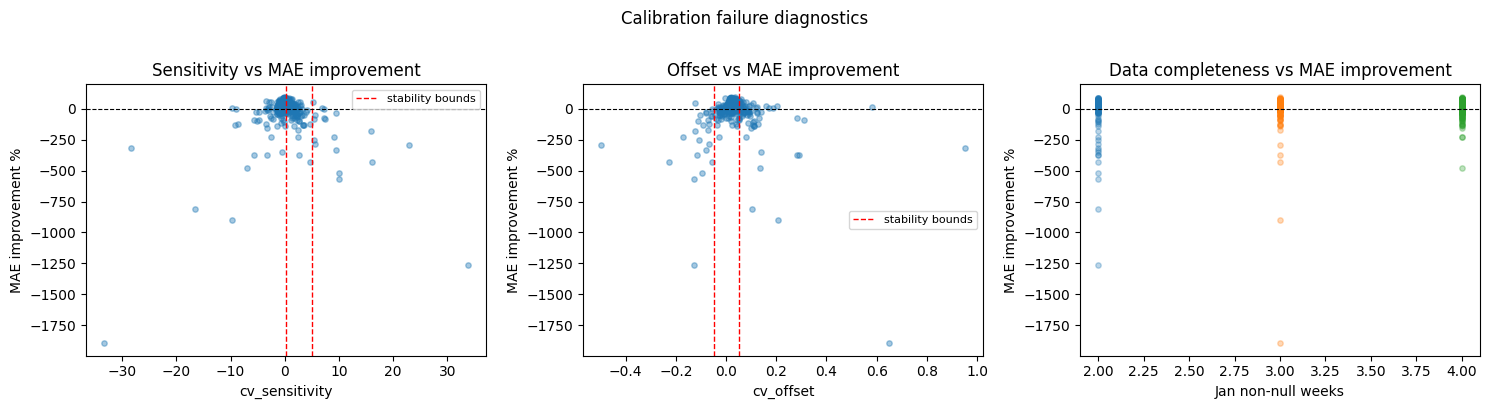

In [114]:
# worst-20 merchant failure analysis: diagnose why calibration hurt these merchants

WORST_N = 20

if len(cv_results_df) > 0:
    worst_merchants = cv_results_df.sort_values('mae_improvement_pct').head(WORST_N).copy()
    print(f'Worst {WORST_N} merchants by MAE improvement % (most negative = calibration hurt most):')
    display(worst_merchants[[
        'merchant_id', 'sarima_mae', 'cal_mae', 'mae_improvement_pct',
        'sarima_rmse', 'cal_rmse', 'rmse_improvement_pct',
        'cv_offset', 'cv_sensitivity', 'n_feb_apr_points', 'model_used',
    ]])

    worst_ids = worst_merchants['merchant_id'].tolist()

    # Jan data quality for worst merchants: how many non-null Jan weeks? avg cost_percent? stdev?
    jan_quality = (
        weekly_test_features[
            (weekly_test_features['merchant_id'].isin(worst_ids))
            & (weekly_test_features['week_of_year'].between(1, 4))
        ]
        .groupby('merchant_id', as_index=False)
        .agg(
            jan_non_null_weeks=('cost_percent', lambda s: s.notna().sum()),
            jan_mean_cost_pct=('cost_percent', 'mean'),
            jan_stdev_cost_pct=('cost_percent', 'std'),
            jan_total_txn=('total_transactions', 'sum'),
        )
    )

    # Full year 2019 data quality
    full_yr_quality = (
        weekly_test_features[weekly_test_features['merchant_id'].isin(worst_ids)]
        .groupby('merchant_id', as_index=False)
        .agg(
            yr_non_null_weeks=('cost_percent', lambda s: s.notna().sum()),
            yr_mean_cost_pct=('cost_percent', 'mean'),
            yr_stdev_cost_pct=('cost_percent', 'std'),
            yr_total_txn=('total_transactions', 'sum'),
        )
    )

    quality_df = jan_quality.merge(full_yr_quality, on='merchant_id', how='left')
    quality_df = quality_df.merge(
        worst_merchants[['merchant_id', 'mae_improvement_pct', 'cv_offset', 'cv_sensitivity']],
        on='merchant_id',
    ).sort_values('mae_improvement_pct')

    print('\nJan + full-2019 data quality for worst merchants:')
    display(quality_df)

    # Calibration stability: flag merchants with unstable calibration params
    # Unstable = sensitivity outside [0.2, 5.0] or |offset| > 0.05
    quality_df['sensitivity_flag'] = ~quality_df['cv_sensitivity'].between(0.2, 5.0)
    quality_df['offset_flag'] = quality_df['cv_offset'].abs() > 0.05
    quality_df['any_flag'] = quality_df['sensitivity_flag'] | quality_df['offset_flag']

    print('\nCalibration stability flags (sensitivity outside [0.2, 5.0] or |offset| > 0.05):')
    print(f"  Sensitivity flag: {quality_df['sensitivity_flag'].sum()} / {WORST_N} merchants")
    print(f"  Offset flag:      {quality_df['offset_flag'].sum()} / {WORST_N} merchants")
    print(f"  Either flag:      {quality_df['any_flag'].sum()} / {WORST_N} merchants")
    display(quality_df[quality_df['any_flag']][[
        'merchant_id', 'mae_improvement_pct', 'cv_sensitivity', 'cv_offset',
        'jan_non_null_weeks', 'jan_mean_cost_pct', 'sensitivity_flag', 'offset_flag',
    ]])

    # MCC-wide calibration instability rate for reference
    all_sens_flag = ~cv_results_df['cv_sensitivity'].between(0.2, 5.0)
    all_offset_flag = cv_results_df['cv_offset'].abs() > 0.05
    print(f'\nMCC-wide instability rate (all {len(cv_results_df)} merchants):')
    print(f"  Sensitivity flag: {all_sens_flag.sum()} / {len(cv_results_df)}"
          f" ({all_sens_flag.mean()*100:.1f}%)")
    print(f"  Offset flag:      {all_offset_flag.sum()} / {len(cv_results_df)}"
          f" ({all_offset_flag.mean()*100:.1f}%)")

    # Scatter: MAE improvement % vs Jan data quality indicators
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    ax = axes[0]
    ax.scatter(cv_results_df['cv_sensitivity'], cv_results_df['mae_improvement_pct'], alpha=0.4, s=15)
    ax.axvline(0.2, color='red', linestyle='--', linewidth=1, label='stability bounds')
    ax.axvline(5.0, color='red', linestyle='--', linewidth=1)
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
    ax.set_xlabel('cv_sensitivity')
    ax.set_ylabel('MAE improvement %')
    ax.set_title('Sensitivity vs MAE improvement')
    ax.legend(fontsize=8)

    ax = axes[1]
    ax.scatter(cv_results_df['cv_offset'], cv_results_df['mae_improvement_pct'], alpha=0.4, s=15)
    ax.axvline(-0.05, color='red', linestyle='--', linewidth=1, label='stability bounds')
    ax.axvline(0.05, color='red', linestyle='--', linewidth=1)
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
    ax.set_xlabel('cv_offset')
    ax.set_ylabel('MAE improvement %')
    ax.set_title('Offset vs MAE improvement')
    ax.legend(fontsize=8)

    # Improvement % by Jan non-null weeks (via cv_results_df joined to merchant_coverage)
    jan_counts = (
        weekly_test_features[weekly_test_features['week_of_year'].between(1, 4)]
        .groupby('merchant_id')['cost_percent']
        .apply(lambda s: s.notna().sum())
        .rename('jan_non_null')
        .reset_index()
    )
    plot_df = cv_results_df.merge(jan_counts, on='merchant_id', how='left')

    ax = axes[2]
    for jn in sorted(plot_df['jan_non_null'].unique()):
        sub = plot_df[plot_df['jan_non_null'] == jn]['mae_improvement_pct']
        ax.scatter([jn] * len(sub), sub, alpha=0.3, s=15, label=f'jan_weeks={int(jn)}')
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
    ax.set_xlabel('Jan non-null weeks')
    ax.set_ylabel('MAE improvement %')
    ax.set_title('Data completeness vs MAE improvement')

    plt.suptitle('Calibration failure diagnostics', y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print('No CV results available for failure analysis.')


Guarded calibration strategy
  Stability rule: sensitivity in [0.2, 5.0] AND |offset| <= 0.05
  Stable  (calibrate):      240 merchants (44.2%)
  Unstable (skip):          303 merchants (55.8%)

Overall strategy comparison (all 543 merchants):


,strategy,mean_MAE,trimmed_mean_MAE (10%),median_MAE,mean_RMSE,trimmed_mean_RMSE (10%),median_RMSE,win_rate_vs_SARIMA_%
0,Never calibrate (pure SARIMA),0.030483,0.021074,0.018822,0.041819,0.026068,0.022855,0.000000
1,Always calibrate,0.030636,0.017027,0.013159,0.044209,0.022436,0.017374,72.375691
2,Guarded calibration,0.028346,0.018587,0.016629,0.039796,0.023643,0.020582,34.438306



Isolated view: unstable merchants only (303 merchants)


,strategy,mean_MAE,median_MAE,mean_RMSE,median_RMSE,median_MAE_improvement_%
0,Raw SARIMA (no calibration),0.028485,0.018400,0.036555,0.021903,0.000000
1,Always calibrate (was applied),0.032590,0.013037,0.044463,0.017651,25.573325
2,Guarded = skip calibration,0.028485,0.018400,0.036555,0.021903,0.000000



Breakdown by stability group:


,stable (calibrated),n_merchants,mean_sarima_mae,mean_cal_mae,mean_guarded_mae,median_mae_improvement,guarded_median_improvement,win_rate_always_cal
0,False,303,0.028485,0.03259,0.028485,25.573325,0.000000,67.986799
1,True,240,0.033005,0.02817,0.028170,22.764345,22.764345,77.916667


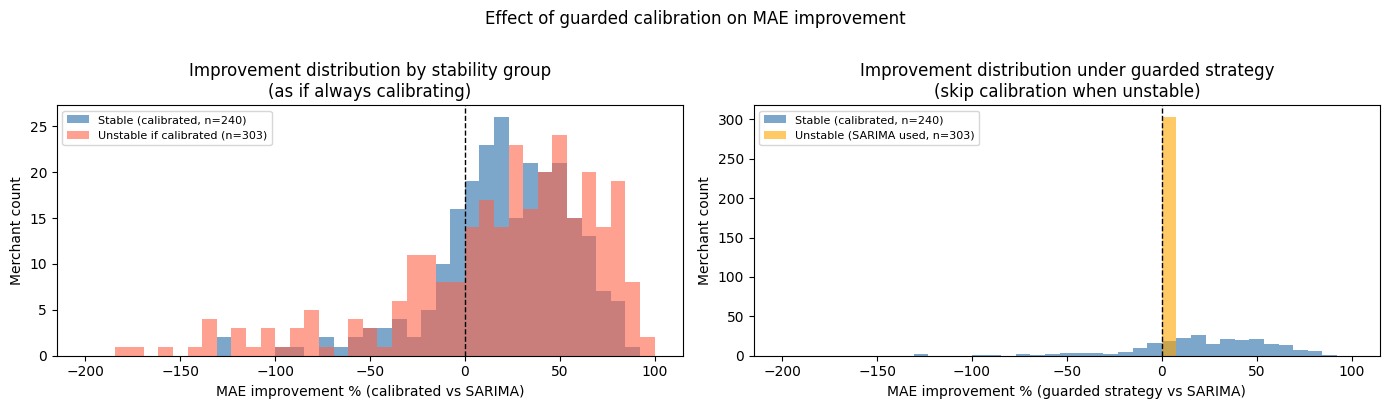


Final headline: guarded calibration vs always-calibrate (all 543 merchants):
  Pure SARIMA mean MAE:        0.030483
  Always-calibrate mean MAE:   0.030636  (-0.50% vs SARIMA)
  Guarded calibration MAE:     0.028346  (+7.01% vs SARIMA)


In [115]:
# guarded calibration: skip calibration for merchants with unstable params, use raw SARIMA instead
# stability rule: sensitivity in [0.2, 5.0] AND |offset| <= 0.05

SENS_MIN, SENS_MAX = 0.2, 5.0
OFFSET_MAX = 0.05

guarded_df = cv_results_df.copy()

stable_mask = (
    guarded_df['cv_sensitivity'].between(SENS_MIN, SENS_MAX)
    & (guarded_df['cv_offset'].abs() <= OFFSET_MAX)
)

guarded_df['calibration_applied'] = stable_mask
guarded_df['guarded_mae'] = np.where(stable_mask, guarded_df['cal_mae'], guarded_df['sarima_mae'])
guarded_df['guarded_rmse'] = np.where(stable_mask, guarded_df['cal_rmse'], guarded_df['sarima_rmse'])
guarded_df['guarded_mae_improvement_pct'] = (
    (guarded_df['sarima_mae'] - guarded_df['guarded_mae'])
    / np.clip(guarded_df['sarima_mae'], 1e-12, None) * 100
)

n_stable = stable_mask.sum()
n_unstable = (~stable_mask).sum()
print('Guarded calibration strategy')
print(f'  Stability rule: sensitivity in [{SENS_MIN}, {SENS_MAX}] AND |offset| <= {OFFSET_MAX}')
print(f'  Stable  (calibrate):      {n_stable} merchants ({n_stable/len(guarded_df)*100:.1f}%)')
print(f'  Unstable (skip):          {n_unstable} merchants ({n_unstable/len(guarded_df)*100:.1f}%)')
print()

# ── Overall comparison: always-calibrate vs guarded vs never-calibrate ──────────
overall_comparison = pd.DataFrame({
    'strategy': ['Never calibrate (pure SARIMA)', 'Always calibrate', 'Guarded calibration'],
    'mean_MAE': [
        guarded_df['sarima_mae'].mean(),
        guarded_df['cal_mae'].mean(),
        guarded_df['guarded_mae'].mean(),
    ],
    'trimmed_mean_MAE (10%)': [
        trimmed_mean(guarded_df['sarima_mae'], 0.10),
        trimmed_mean(guarded_df['cal_mae'], 0.10),
        trimmed_mean(guarded_df['guarded_mae'], 0.10),
    ],
    'median_MAE': [
        guarded_df['sarima_mae'].median(),
        guarded_df['cal_mae'].median(),
        guarded_df['guarded_mae'].median(),
    ],
    'mean_RMSE': [
        guarded_df['sarima_rmse'].mean(),
        guarded_df['cal_rmse'].mean(),
        guarded_df['guarded_rmse'].mean(),
    ],
    'trimmed_mean_RMSE (10%)': [
        trimmed_mean(guarded_df['sarima_rmse'], 0.10),
        trimmed_mean(guarded_df['cal_rmse'], 0.10),
        trimmed_mean(guarded_df['guarded_rmse'], 0.10),
    ],
    'median_RMSE': [
        guarded_df['sarima_rmse'].median(),
        guarded_df['cal_rmse'].median(),
        guarded_df['guarded_rmse'].median(),
    ],
    'win_rate_vs_SARIMA_%': [
        0.0,
        (guarded_df['cal_mae'] < guarded_df['sarima_mae']).mean() * 100,
        (guarded_df['guarded_mae'] < guarded_df['sarima_mae']).mean() * 100,
    ],
})

print('Overall strategy comparison (all 543 merchants):')
display(overall_comparison)

# ── Isolated view: just the unstable 27% merchants ───────────────────────────
unstable_df = guarded_df[~stable_mask].copy()
print(f'\nIsolated view: unstable merchants only ({len(unstable_df)} merchants)')

unstable_comparison = pd.DataFrame({
    'strategy': ['Raw SARIMA (no calibration)', 'Always calibrate (was applied)', 'Guarded = skip calibration'],
    'mean_MAE': [
        unstable_df['sarima_mae'].mean(),
        unstable_df['cal_mae'].mean(),
        unstable_df['guarded_mae'].mean(),    # same as sarima_mae for unstable
    ],
    'median_MAE': [
        unstable_df['sarima_mae'].median(),
        unstable_df['cal_mae'].median(),
        unstable_df['guarded_mae'].median(),
    ],
    'mean_RMSE': [
        unstable_df['sarima_rmse'].mean(),
        unstable_df['cal_rmse'].mean(),
        unstable_df['guarded_rmse'].mean(),
    ],
    'median_RMSE': [
        unstable_df['sarima_rmse'].median(),
        unstable_df['cal_rmse'].median(),
        unstable_df['guarded_rmse'].median(),
    ],
    'median_MAE_improvement_%': [
        0.0,
        unstable_df['mae_improvement_pct'].median(),
        0.0,   # skipping calibration = no change from SARIMA baseline
    ],
})
display(unstable_comparison)

# ── Summary: improvement breakdown by stability group ────────────────────────
group_summary = (
    guarded_df.groupby('calibration_applied', as_index=False)
    .agg(
        n_merchants=('merchant_id', 'count'),
        mean_sarima_mae=('sarima_mae', 'mean'),
        mean_cal_mae=('cal_mae', 'mean'),
        mean_guarded_mae=('guarded_mae', 'mean'),
        median_mae_improvement=('mae_improvement_pct', 'median'),
        guarded_median_improvement=('guarded_mae_improvement_pct', 'median'),
        win_rate_always_cal=('cal_mae', lambda s: (s < guarded_df.loc[s.index, 'sarima_mae']).mean() * 100),
    )
    .rename(columns={'calibration_applied': 'stable (calibrated)'})
)
print('\nBreakdown by stability group:')
display(group_summary)

# ── Visualisation: side-by-side improvement distributions ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
bins = np.linspace(-200, 100, 40)
ax.hist(guarded_df.loc[stable_mask, 'mae_improvement_pct'], bins=bins, alpha=0.7, label=f'Stable (calibrated, n={n_stable})', color='steelblue')
ax.hist(guarded_df.loc[~stable_mask, 'mae_improvement_pct'], bins=bins, alpha=0.6, label=f'Unstable if calibrated (n={n_unstable})', color='tomato')
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('MAE improvement % (calibrated vs SARIMA)')
ax.set_ylabel('Merchant count')
ax.set_title('Improvement distribution by stability group\n(as if always calibrating)')
ax.legend(fontsize=8)

ax = axes[1]
guarded_improvement_all = (guarded_df['sarima_mae'] - guarded_df['guarded_mae']) / guarded_df['sarima_mae'].clip(lower=1e-12) * 100
ax.hist(guarded_df.loc[stable_mask, 'guarded_mae_improvement_pct'], bins=bins, alpha=0.7, label=f'Stable (calibrated, n={n_stable})', color='steelblue')
ax.hist([0] * n_unstable, bins=bins, alpha=0.6, label=f'Unstable (SARIMA used, n={n_unstable})', color='orange')
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('MAE improvement % (guarded strategy vs SARIMA)')
ax.set_ylabel('Merchant count')
ax.set_title('Improvement distribution under guarded strategy\n(skip calibration when unstable)')
ax.legend(fontsize=8)

plt.suptitle('Effect of guarded calibration on MAE improvement', y=1.01)
plt.tight_layout()
plt.show()

print('\nFinal headline: guarded calibration vs always-calibrate (all 543 merchants):')
g_mae = guarded_df['guarded_mae'].mean()
a_mae = guarded_df['cal_mae'].mean()
s_mae = guarded_df['sarima_mae'].mean()
print(f'  Pure SARIMA mean MAE:        {s_mae:.6f}')
print(f'  Always-calibrate mean MAE:   {a_mae:.6f}  ({(s_mae-a_mae)/s_mae*100:+.2f}% vs SARIMA)')
print(f'  Guarded calibration MAE:     {g_mae:.6f}  ({(s_mae-g_mae)/s_mae*100:+.2f}% vs SARIMA)')


Policy-search grid complete
Policies evaluated: 240
Original unstable merchants under hard guard: 303
Hard-guard portfolio mean MAE: 0.028346

Best trade-off policy (within MAE tolerance):
  sensitivity in [0.00, 8.00], |offset| <= 0.30
  Portfolio mean MAE: 0.028332
  Unstable calibrated: 94/303 (31.0%)
  Retained unstable wins: 64 (win rate 68.1% among calibrated unstable)

Top 15 by portfolio mean MAE:


,sens_min,sens_max,offset_max,portfolio_mean_mae,portfolio_trimmed_mae_10,unstable_calibrated_n,unstable_calibrated_rate_pct,unstable_retained_wins_n,unstable_retained_win_rate_pct,p99_mae_worsening_vs_sarima
0,0.0,5.0,0.06,0.027482,0.017648,70,23.102310,58,82.857143,0.017454
1,0.0,6.0,0.06,0.027499,0.017661,72,23.762376,59,81.944444,0.018019
2,0.0,10.0,0.06,0.027525,0.017692,75,24.752475,60,80.000000,0.018019
3,0.0,30.0,0.06,0.027525,0.017692,75,24.752475,60,80.000000,0.018019
4,0.0,15.0,0.06,0.027525,0.017692,75,24.752475,60,80.000000,0.018019
5,0.0,12.0,0.06,0.027525,0.017692,75,24.752475,60,80.000000,0.018019
6,0.0,20.0,0.06,0.027525,0.017692,75,24.752475,60,80.000000,0.018019
7,0.0,8.0,0.06,0.027525,0.017692,75,24.752475,60,80.000000,0.018019
8,0.0,5.0,0.05,0.027584,0.017784,60,19.801980,52,86.666667,0.016379
9,0.0,6.0,0.05,0.027601,0.017801,62,20.462046,53,85.483871,0.017454



Top 15 trade-off candidates (retain unstable wins subject to MAE tolerance):


,sens_min,sens_max,offset_max,portfolio_mean_mae,portfolio_trimmed_mae_10,unstable_calibrated_n,unstable_calibrated_rate_pct,unstable_retained_wins_n,unstable_retained_win_rate_pct,p99_mae_worsening_vs_sarima
0,0.0,8.0,0.30,0.028332,0.018056,94,31.023102,64,68.085106,0.038045
1,0.0,8.0,0.50,0.028332,0.018056,94,31.023102,64,68.085106,0.038045
2,0.0,8.0,1.00,0.028332,0.018056,94,31.023102,64,68.085106,0.038045
3,0.0,8.0,0.20,0.028154,0.018056,92,30.363036,63,68.478261,0.033736
4,0.0,8.0,0.15,0.028154,0.018056,92,30.363036,63,68.478261,0.033736
5,0.0,6.0,1.00,0.028073,0.018024,90,29.702970,63,70.000000,0.033736
6,0.0,6.0,0.50,0.028073,0.018024,90,29.702970,63,70.000000,0.033736
7,0.0,6.0,0.30,0.028073,0.018024,90,29.702970,63,70.000000,0.033736
8,0.0,30.0,0.12,0.028468,0.018193,94,31.023102,62,65.957447,0.038450
9,0.0,10.0,0.12,0.028468,0.018193,94,31.023102,62,65.957447,0.038450


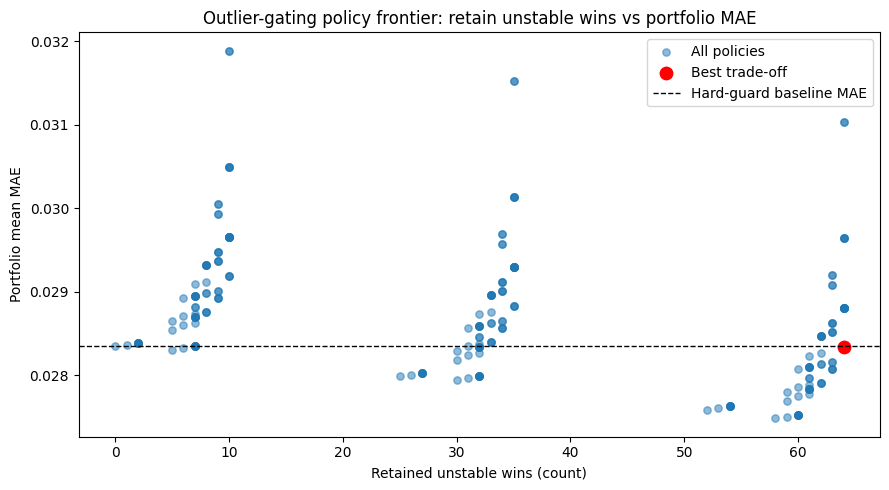

In [116]:
# outlier-aware policy search: keep some unstable calibrations while controlling portfolio MAE tail risk
# note: this is retrospective policy evaluation on the current CV table (use as design guidance)

policy_df = cv_results_df.copy()

# Baseline from current hard guard
base_sens_min, base_sens_max, base_offset_max = 0.2, 5.0, 0.05
base_apply = policy_df['cv_sensitivity'].between(base_sens_min, base_sens_max) & (policy_df['cv_offset'].abs() <= base_offset_max)
base_mae = np.where(base_apply, policy_df['cal_mae'], policy_df['sarima_mae']).mean()

# Define "original unstable" set using current hard-guard rule.
orig_unstable = ~base_apply
n_orig_unstable = int(orig_unstable.sum())

sens_min_grid = [0.0, 0.1, 0.2]
sens_max_grid = [5.0, 6.0, 8.0, 10.0, 12.0, 15.0, 20.0, 30.0]
offset_max_grid = [0.05, 0.06, 0.08, 0.10, 0.12, 0.15, 0.20, 0.30, 0.50, 1.00]

rows = []
for smin in sens_min_grid:
    for smax in sens_max_grid:
        if smax <= smin:
            continue
        for omax in offset_max_grid:
            apply_mask = policy_df['cv_sensitivity'].between(smin, smax) & (policy_df['cv_offset'].abs() <= omax)

            chosen_mae = np.where(apply_mask, policy_df['cal_mae'], policy_df['sarima_mae'])
            chosen_rmse = np.where(apply_mask, policy_df['cal_rmse'], policy_df['sarima_rmse'])

            # Track how much of the original unstable segment is retained for calibration.
            unstable_applied_mask = apply_mask & orig_unstable
            unstable_applied_n = int(unstable_applied_mask.sum())
            unstable_applied_rate = unstable_applied_n / max(n_orig_unstable, 1)

            # Among retained unstable calibrations, how often was calibration actually better?
            if unstable_applied_n > 0:
                unstable_win_rate = (
                    policy_df.loc[unstable_applied_mask, 'cal_mae']
                    < policy_df.loc[unstable_applied_mask, 'sarima_mae']
                ).mean() * 100
                unstable_retained_wins = int((
                    policy_df.loc[unstable_applied_mask, 'cal_mae']
                    < policy_df.loc[unstable_applied_mask, 'sarima_mae']
                ).sum())
            else:
                unstable_win_rate = np.nan
                unstable_retained_wins = 0

            # Tail-risk proxy: worst 1% MAE delta vs SARIMA for this policy.
            mae_delta_vs_sarima = chosen_mae - policy_df['sarima_mae'].values
            p99_worsening = np.percentile(mae_delta_vs_sarima, 99)

            rows.append(
                {
                    'sens_min': smin,
                    'sens_max': smax,
                    'offset_max': omax,
                    'n_calibrated_total': int(apply_mask.sum()),
                    'portfolio_mean_mae': float(np.mean(chosen_mae)),
                    'portfolio_mean_rmse': float(np.mean(chosen_rmse)),
                    'portfolio_trimmed_mae_10': float(trimmed_mean(pd.Series(chosen_mae), 0.10)),
                    'portfolio_trimmed_rmse_10': float(trimmed_mean(pd.Series(chosen_rmse), 0.10)),
                    'unstable_calibrated_n': unstable_applied_n,
                    'unstable_calibrated_rate_pct': float(unstable_applied_rate * 100),
                    'unstable_retained_wins_n': unstable_retained_wins,
                    'unstable_retained_win_rate_pct': float(unstable_win_rate) if not np.isnan(unstable_win_rate) else np.nan,
                    'p99_mae_worsening_vs_sarima': float(p99_worsening),
                }
            )

policy_search_df = pd.DataFrame(rows).sort_values('portfolio_mean_mae').reset_index(drop=True)

print('Policy-search grid complete')
print(f'Policies evaluated: {len(policy_search_df)}')
print(f'Original unstable merchants under hard guard: {n_orig_unstable}')
print(f'Hard-guard portfolio mean MAE: {base_mae:.6f}')

# Candidate set: near-best MAE while maximizing unstable-retained wins.
# Allow <= 0.5% MAE degradation from hard-guard baseline.
mae_tolerance = 0.005
max_allowed_mae = base_mae * (1.0 + mae_tolerance)

candidate_df = policy_search_df[
    policy_search_df['portfolio_mean_mae'] <= max_allowed_mae
].copy()

if len(candidate_df) == 0:
    candidate_df = policy_search_df.head(20).copy()

# Rank by: retained unstable wins, then unstable calibrated coverage, then lowest mean MAE.
candidate_ranked = candidate_df.sort_values(
    ['unstable_retained_wins_n', 'unstable_calibrated_rate_pct', 'portfolio_mean_mae'],
    ascending=[False, False, True],
).reset_index(drop=True)

best_tradeoff = candidate_ranked.iloc[0].copy()

print('\nBest trade-off policy (within MAE tolerance):')
print(
    f"  sensitivity in [{best_tradeoff['sens_min']:.2f}, {best_tradeoff['sens_max']:.2f}], "
    f"|offset| <= {best_tradeoff['offset_max']:.2f}"
)
print(f"  Portfolio mean MAE: {best_tradeoff['portfolio_mean_mae']:.6f}")
print(f"  Unstable calibrated: {int(best_tradeoff['unstable_calibrated_n'])}/{n_orig_unstable} "
      f"({best_tradeoff['unstable_calibrated_rate_pct']:.1f}%)")
print(f"  Retained unstable wins: {int(best_tradeoff['unstable_retained_wins_n'])} "
      f"(win rate {best_tradeoff['unstable_retained_win_rate_pct']:.1f}% among calibrated unstable)")

print('\nTop 15 by portfolio mean MAE:')
display(
    policy_search_df[
        [
            'sens_min', 'sens_max', 'offset_max',
            'portfolio_mean_mae', 'portfolio_trimmed_mae_10',
            'unstable_calibrated_n', 'unstable_calibrated_rate_pct',
            'unstable_retained_wins_n', 'unstable_retained_win_rate_pct',
            'p99_mae_worsening_vs_sarima',
        ]
    ].head(15)
)

print('\nTop 15 trade-off candidates (retain unstable wins subject to MAE tolerance):')
display(
    candidate_ranked[
        [
            'sens_min', 'sens_max', 'offset_max',
            'portfolio_mean_mae', 'portfolio_trimmed_mae_10',
            'unstable_calibrated_n', 'unstable_calibrated_rate_pct',
            'unstable_retained_wins_n', 'unstable_retained_win_rate_pct',
            'p99_mae_worsening_vs_sarima',
        ]
    ].head(15)
)

# Visualize frontier: MAE vs unstable-retained wins
plt.figure(figsize=(9, 5))
plt.scatter(
    policy_search_df['unstable_retained_wins_n'],
    policy_search_df['portfolio_mean_mae'],
    alpha=0.5,
    s=28,
    label='All policies',
)
plt.scatter(
    [best_tradeoff['unstable_retained_wins_n']],
    [best_tradeoff['portfolio_mean_mae']],
    color='red',
    s=80,
    label='Best trade-off',
)
plt.axhline(base_mae, color='black', linestyle='--', linewidth=1, label='Hard-guard baseline MAE')
plt.xlabel('Retained unstable wins (count)')
plt.ylabel('Portfolio mean MAE')
plt.title('Outlier-gating policy frontier: retain unstable wins vs portfolio MAE')
plt.legend()
plt.tight_layout()
plt.show()


In [117]:
# deployable decision rule: policy profiles + production gating function

# Build a clean baseline from the current hard-guard rule.
hard_guard_mae = base_mae
hard_guard_rmse = np.where(base_apply, policy_df['cal_rmse'], policy_df['sarima_rmse']).mean()

search_df = policy_search_df.copy()

# Profile 1: conservative (tight tail control, prioritize MAE stability)
cons_candidates = search_df[
    (search_df['p99_mae_worsening_vs_sarima'] <= 0.020)
    & (search_df['unstable_calibrated_rate_pct'] >= 15)
].copy()
if len(cons_candidates) == 0:
    cons_candidates = search_df.copy()
conservative = cons_candidates.sort_values('portfolio_mean_mae').iloc[0]

# Profile 2: balanced (near hard-guard MAE, maximize retained unstable wins)
bal_candidates = search_df[
    search_df['portfolio_mean_mae'] <= hard_guard_mae * 1.002
].copy()
if len(bal_candidates) == 0:
    bal_candidates = search_df.copy()
balanced = bal_candidates.sort_values(
    ['unstable_retained_wins_n', 'portfolio_mean_mae'],
    ascending=[False, True],
).iloc[0]

# Profile 3: aggressive (more calibration coverage with bounded MAE drift)
agg_candidates = search_df[
    (search_df['portfolio_mean_mae'] <= hard_guard_mae * 1.010)
    & (search_df['p99_mae_worsening_vs_sarima'] <= 0.050)
].copy()
if len(agg_candidates) == 0:
    agg_candidates = search_df.copy()
aggressive = agg_candidates.sort_values(
    ['unstable_calibrated_n', 'unstable_retained_wins_n', 'portfolio_mean_mae'],
    ascending=[False, False, True],
).iloc[0]

selected_profiles = pd.DataFrame([
    {
        'profile': 'conservative',
        'sens_min': conservative['sens_min'],
        'sens_max': conservative['sens_max'],
        'offset_max': conservative['offset_max'],
        'portfolio_mean_mae': conservative['portfolio_mean_mae'],
        'portfolio_mean_rmse': conservative['portfolio_mean_rmse'],
        'delta_mae_vs_hard_guard_pct': (hard_guard_mae - conservative['portfolio_mean_mae']) / hard_guard_mae * 100,
        'unstable_calibrated_n': conservative['unstable_calibrated_n'],
        'unstable_retained_wins_n': conservative['unstable_retained_wins_n'],
        'unstable_retained_win_rate_pct': conservative['unstable_retained_win_rate_pct'],
        'p99_mae_worsening_vs_sarima': conservative['p99_mae_worsening_vs_sarima'],
    },
    {
        'profile': 'balanced',
        'sens_min': balanced['sens_min'],
        'sens_max': balanced['sens_max'],
        'offset_max': balanced['offset_max'],
        'portfolio_mean_mae': balanced['portfolio_mean_mae'],
        'portfolio_mean_rmse': balanced['portfolio_mean_rmse'],
        'delta_mae_vs_hard_guard_pct': (hard_guard_mae - balanced['portfolio_mean_mae']) / hard_guard_mae * 100,
        'unstable_calibrated_n': balanced['unstable_calibrated_n'],
        'unstable_retained_wins_n': balanced['unstable_retained_wins_n'],
        'unstable_retained_win_rate_pct': balanced['unstable_retained_win_rate_pct'],
        'p99_mae_worsening_vs_sarima': balanced['p99_mae_worsening_vs_sarima'],
    },
    {
        'profile': 'aggressive',
        'sens_min': aggressive['sens_min'],
        'sens_max': aggressive['sens_max'],
        'offset_max': aggressive['offset_max'],
        'portfolio_mean_mae': aggressive['portfolio_mean_mae'],
        'portfolio_mean_rmse': aggressive['portfolio_mean_rmse'],
        'delta_mae_vs_hard_guard_pct': (hard_guard_mae - aggressive['portfolio_mean_mae']) / hard_guard_mae * 100,
        'unstable_calibrated_n': aggressive['unstable_calibrated_n'],
        'unstable_retained_wins_n': aggressive['unstable_retained_wins_n'],
        'unstable_retained_win_rate_pct': aggressive['unstable_retained_win_rate_pct'],
        'p99_mae_worsening_vs_sarima': aggressive['p99_mae_worsening_vs_sarima'],
    },
])

print('Deployable policy profiles (choose by risk appetite):')
display(selected_profiles)

# Recommended default profile for deployment.
# Here we choose balanced as default.
default_profile = 'balanced'
default_row = selected_profiles[selected_profiles['profile'] == default_profile].iloc[0]

DEPLOY_POLICY = {
    'profile': default_profile,
    'sensitivity_min': float(default_row['sens_min']),
    'sensitivity_max': float(default_row['sens_max']),
    'offset_abs_max': float(default_row['offset_max']),
}

print('\nRecommended deploy config:')
print(DEPLOY_POLICY)


def should_apply_calibration(cv_sensitivity, cv_offset, policy=DEPLOY_POLICY):
    """Return True if merchant passes gating rule for calibration."""
    return (
        (cv_sensitivity >= policy['sensitivity_min'])
        and (cv_sensitivity <= policy['sensitivity_max'])
        and (abs(cv_offset) <= policy['offset_abs_max'])
    )


def apply_gated_calibration(sarima_pred, cv_offset, cv_sensitivity, policy=DEPLOY_POLICY):
    """
    Production scoring rule:
    - If gate passes, use calibrated prediction: offset + sensitivity * sarima_pred
    - Otherwise, fallback to raw sarima_pred
    """
    if should_apply_calibration(cv_sensitivity=cv_sensitivity, cv_offset=cv_offset, policy=policy):
        return cv_offset + cv_sensitivity * sarima_pred
    return sarima_pred


# Quick backtest verification using the selected default policy.
verif_apply = (
    policy_df['cv_sensitivity'].between(DEPLOY_POLICY['sensitivity_min'], DEPLOY_POLICY['sensitivity_max'])
    & (policy_df['cv_offset'].abs() <= DEPLOY_POLICY['offset_abs_max'])
)

verif_mae = np.where(verif_apply, policy_df['cal_mae'], policy_df['sarima_mae']).mean()
verif_rmse = np.where(verif_apply, policy_df['cal_rmse'], policy_df['sarima_rmse']).mean()

print('\nBacktest verification for default deploy policy:')
print(f'  Hard-guard MAE baseline: {hard_guard_mae:.6f}')
print(f'  Deploy-policy MAE:       {verif_mae:.6f} ({(hard_guard_mae-verif_mae)/hard_guard_mae*100:+.2f}% vs hard-guard)')
print(f'  Hard-guard RMSE baseline:{hard_guard_rmse:.6f}')
print(f'  Deploy-policy RMSE:      {verif_rmse:.6f} ({(hard_guard_rmse-verif_rmse)/hard_guard_rmse*100:+.2f}% vs hard-guard)')
print(f'  Merchants calibrated under deploy policy: {int(verif_apply.sum())}/{len(verif_apply)}')


Deployable policy profiles (choose by risk appetite):


,profile,sens_min,sens_max,offset_max,portfolio_mean_mae,portfolio_mean_rmse,delta_mae_vs_hard_guard_pct,unstable_calibrated_n,unstable_retained_wins_n,unstable_retained_win_rate_pct,p99_mae_worsening_vs_sarima
0,conservative,0.0,5.0,0.06,0.027482,0.039013,3.045893,70.0,58.0,82.857143,0.017454
1,balanced,0.0,8.0,0.30,0.028332,0.039827,0.049004,94.0,64.0,68.085106,0.038045
2,aggressive,0.0,15.0,0.15,0.028512,0.040057,-0.585562,96.0,63.0,65.625000,0.048597



Recommended deploy config:
{'profile': 'balanced', 'sensitivity_min': 0.0, 'sensitivity_max': 8.0, 'offset_abs_max': 0.3}

Backtest verification for default deploy policy:
  Hard-guard MAE baseline: 0.028346
  Deploy-policy MAE:       0.028332 (+0.05% vs hard-guard)
  Hard-guard RMSE baseline:0.039796
  Deploy-policy RMSE:      0.039827 (-0.08% vs hard-guard)
  Merchants calibrated under deploy policy: 334/543


# Workbook Results and Deployment Plan (Python Service)

## 1) Executive Summary
This workbook evaluates a leakage-safe merchant forecasting pipeline:
- Weekly merchant feature engineering (2017/2018 history + 2019 evaluation)
- KNN neighbor retrieval for analog merchant selection
- Composite merchant construction
- SARIMA forecasting
- Optional linear calibration (`actual ~= offset + sensitivity * sarima_pred`)
- MCC-wide cross-validation with leave-one-merchant-out pools

## 2) Data Flow (Training to Serving)
Use this as the end-to-end contract for implementation and operations.

1. Raw transaction data -> weekly merchant features
- Inputs: transaction-level records (`merchant_id`, `date`, `amount`, `proc_cost`, `cost_type_ID`)
- Transform: aggregate to merchant-week features (`cost_percent`, `total_transactions`, cost-type mix, volatility stats)
- Output: normalized weekly panel by merchant

2. Candidate merchant scoring -> nearest-neighbor retrieval
- Inputs: Jan weeks 1-4 trajectory for target merchant + historical merchant pool
- Transform: standardize features, build week-sequence vectors, run k-NN
- Output: top-K neighbor merchants with distances and weights

3. Composite history creation
- Inputs: neighbor merchant weekly history (2017-2018) + neighbor weights
- Transform: weighted aggregation to a synthetic composite merchant timeline
- Output: one continuous training series for SARIMA

4. Single-shot inference (`POST /sarima_single_shot`)
- Inputs:
  - `composite_weekly_history` (from k-NN composite module)
  - `query_monthly_actuals` (query merchant 1 month weekly actuals, typically 4 points)
  - `forecast_horizon`, `alpha`, `profile`
- Transform (inside one endpoint):
  - auto-select `order` + `seasonal_order` by AIC and fit SARIMA
  - generate reference SARIMA for query month
  - fit calibration params (`cv_offset`, `cv_sensitivity`) from query month
  - evaluate stability status against selected policy thresholds
  - evaluate outlier status from residual diagnostics
  - produce final forecasts with gated calibration
- Output: SARIMA settings, forecasts, confidence intervals, calibration decision, stability status, and outlier status

5. Monitoring and control loop
- Inputs: online actuals + inference logs
- Transform: compute MAE/RMSE drift, calibration apply-rate, tail-error percentiles
- Output: profile tuning decisions and safe rollback to pure SARIMA when needed

## 3) Key Validation Results
From MCC-wide CV (543 merchants):
- Calibration improved MAE for ~72.38% of merchants
- Calibration improved RMSE for ~72.93% of merchants
- Median improvement was positive (MAE and RMSE)
- Raw mean metrics were pulled down by a long negative outlier tail

Interpretation:
- Calibration helps most merchants
- A minority of unstable calibrations can create large portfolio MAE losses
- Therefore, calibration should be gated by outlier-aware decision rules

## 4) Outlier-Aware Decision Rule (Deployable)
Policy search tested sensitivity/offset gates to preserve useful unstable wins while controlling tail risk.

Recommended default deploy profile (`balanced`):
- `sensitivity_min = 0.0`
- `sensitivity_max = 8.0`
- `offset_abs_max = 0.30`

Backtest (vs hard-guard baseline):
- Hard-guard MAE: `0.028346`
- Deploy-policy MAE: `0.028332` (slight improvement)
- Hard-guard RMSE: `0.039796`
- Deploy-policy RMSE: `0.039827` (near-neutral)
- Merchants calibrated under deploy policy: `334 / 543`

## 5) API Surface (FastAPI)
- `GET /health`: liveness/readiness check
- `POST /sarima_single_shot`: one-call pipeline (fit + calibrate + diagnose + forecast)

Core runtime logic:

```python
def should_apply_calibration(cv_sensitivity, cv_offset, policy):
    return (
        policy['sensitivity_min'] <= cv_sensitivity <= policy['sensitivity_max']
        and abs(cv_offset) <= policy['offset_abs_max']
    )


def apply_gated_calibration(sarima_pred, cv_offset, cv_sensitivity, policy):
    if should_apply_calibration(cv_sensitivity, cv_offset, policy):
        return cv_offset + cv_sensitivity * sarima_pred, True
    return sarima_pred, False
```

## 6) Updated Deployment Steps (Runbook)
1. Environment and dependencies
- Create and activate runtime environment
- Install service dependencies (`fastapi`, `uvicorn`, `pydantic`, `statsmodels`, `numpy`, `pandas`, `scikit-learn`)
- Validate with `GET /health` once service starts

2. Upstream contract (k-NN module -> service)
- Ensure k-NN module sends composite weekly series as `composite_weekly_history`
- Ensure scoring layer sends query merchant month actuals as `query_monthly_actuals`
- Validate payload lengths and numeric data quality before call

3. Single-endpoint integration
- Call `POST /sarima_single_shot` with history + query month + horizon/profile
- Persist returned model diagnostics (`order`, `seasonal_order`, `aic`)
- Persist risk diagnostics (`stability_status`, `outlier_status`) with predictions

```python
class AutoSarimaSingleResponse(BaseModel):
    model_used: str
    order: List[int]
    seasonal_order: List[int]
    train_points: int
    aic: float
    profile: str
    cv_offset: float
    cv_sensitivity: float
    calibration_applied: bool
    stability_status: StabilityStatus
    outlier_status: OutlierStatus
    calibration_reference_pred: List[float]
    calibration_reference_actual: List[float]
    sarima_predictions: List[float]
    final_predictions: List[float]
    ci_lower: List[float]
    ci_upper: List[float]
```

4. Observability and reliability controls
- Log per request: profile, calibration decision, outlier/stability flags, output stats
- Track KPIs: MAE/RMSE drift, apply-rate, p95/p99 absolute error, outlier-rate
- Add alerts for sustained drift and a rollback switch to conservative policy or no-calibration mode

5. Promotion and rollback strategy
- Stage -> canary -> full rollout
- Compare `conservative` vs `balanced` where risk appetite differs
- Keep one-click rollback to previous profile

## 7) Suggested Next Step
Add a lightweight request/response audit table so every single-shot call is traceable by timestamp, profile, selected SARIMA orders, stability flag, and outlier flag.

In [5]:
# Service implementation (FastAPI): single-endpoint SARIMA pipeline
from itertools import product
from typing import Any, Dict, List, Literal, Optional

import numpy as np
import pandas as pd
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel, Field, model_validator
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.statespace.sarimax import SARIMAX

# ------------------------------
# Runtime policy configuration
# ------------------------------
POLICY_PROFILES: Dict[str, Dict[str, float]] = {
    'conservative': {
        'sensitivity_min': 0.0,
        'sensitivity_max': 5.0,
        'offset_abs_max': 0.06,
    },
    'balanced': {
        'sensitivity_min': 0.0,
        'sensitivity_max': 8.0,
        'offset_abs_max': 0.30,
    },
    'aggressive': {
        'sensitivity_min': 0.0,
        'sensitivity_max': 15.0,
        'offset_abs_max': 0.15,
    },
}

DEFAULT_PROFILE = 'balanced'


def prepare_series(historical_series: List[float]) -> pd.Series:
    if not historical_series:
        raise ValueError('composite_weekly_history must contain at least 1 value.')
    y = pd.Series(historical_series, dtype=float)
    y = y.interpolate(limit_direction='both').ffill().bfill()
    return y


def infer_seasonal_period(n_points: int) -> int:
    if n_points >= 104:
        return 52
    if n_points >= 52:
        return 26
    if n_points >= 24:
        return 12
    return 0


def auto_select_sarima_orders(y_train: pd.Series) -> Dict[str, Any]:
    n_points = int(len(y_train))
    seasonal_period = infer_seasonal_period(n_points)

    pdq_grid = list(product([0, 1, 2], [0, 1], [0, 1, 2]))
    seasonal_grid = list(product([0, 1], [0, 1], [0, 1]))

    best = {
        'aic': np.inf,
        'result': None,
        'order': None,
        'seasonal_order': None,
    }

    if seasonal_period > 0:
        for order in pdq_grid:
            for seas in seasonal_grid:
                seasonal_order = (seas[0], seas[1], seas[2], seasonal_period)
                try:
                    model = SARIMAX(
                        y_train,
                        order=order,
                        seasonal_order=seasonal_order,
                        enforce_stationarity=False,
                        enforce_invertibility=False,
                    )
                    result = model.fit(disp=False)
                    if np.isfinite(result.aic) and result.aic < best['aic']:
                        best = {
                            'aic': float(result.aic),
                            'result': result,
                            'order': order,
                            'seasonal_order': seasonal_order,
                        }
                except Exception:
                    continue

    if best['result'] is None:
        for order in pdq_grid:
            seasonal_order = (0, 0, 0, 0)
            try:
                model = SARIMAX(
                    y_train,
                    order=order,
                    seasonal_order=seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False,
                )
                result = model.fit(disp=False)
                if np.isfinite(result.aic) and result.aic < best['aic']:
                    best = {
                        'aic': float(result.aic),
                        'result': result,
                        'order': order,
                        'seasonal_order': seasonal_order,
                    }
            except Exception:
                continue

    if best['result'] is None:
        order = (1, 1, 1)
        seasonal_order = (0, 0, 0, 0)
        model = SARIMAX(
            y_train,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False,
        )
        result = model.fit(disp=False)
        best = {
            'aic': float(result.aic) if np.isfinite(result.aic) else np.inf,
            'result': result,
            'order': order,
            'seasonal_order': seasonal_order,
        }

    model_used = f"SARIMA{best['order']}x{best['seasonal_order']}"
    return {
        'result': best['result'],
        'model_used': model_used,
        'order': best['order'],
        'seasonal_order': best['seasonal_order'],
        'seasonal_period': seasonal_period,
        'aic': best['aic'],
    }


def forecast_sarima(result: Any, steps: int, alpha: float = 0.05) -> Dict[str, List[float]]:
    if steps < 1:
        raise ValueError('forecast_horizon must be >= 1.')

    fc = result.get_forecast(steps=steps)
    yhat = fc.predicted_mean.values.astype(float)
    ci = fc.conf_int(alpha=alpha)

    return {
        'sarima_predictions': yhat.tolist(),
        'ci_lower': ci.iloc[:, 0].astype(float).tolist(),
        'ci_upper': ci.iloc[:, 1].astype(float).tolist(),
    }


def should_apply_calibration(cv_sensitivity: float, cv_offset: float, profile: str = DEFAULT_PROFILE) -> bool:
    policy = POLICY_PROFILES[profile]
    return (
        policy['sensitivity_min'] <= cv_sensitivity <= policy['sensitivity_max']
        and abs(cv_offset) <= policy['offset_abs_max']
    )


def calibration_status(cv_offset: float, cv_sensitivity: float, profile: str) -> Dict[str, Any]:
    policy = POLICY_PROFILES[profile]
    sensitivity_ok = policy['sensitivity_min'] <= cv_sensitivity <= policy['sensitivity_max']
    offset_ok = abs(cv_offset) <= policy['offset_abs_max']
    stable = bool(sensitivity_ok and offset_ok)
    return {
        'stable': stable,
        'sensitivity_ok': bool(sensitivity_ok),
        'offset_ok': bool(offset_ok),
        'reason': 'within_profile_thresholds' if stable else 'outside_profile_thresholds',
        'policy_thresholds': policy,
    }


def fit_linear_calibration(sarima_preds: List[float], actuals: List[float]) -> Dict[str, float]:
    x = np.asarray(sarima_preds, dtype=float).reshape(-1, 1)
    y = np.asarray(actuals, dtype=float)
    if len(y) < 2:
        raise ValueError('query_monthly_actuals must contain at least 2 values for calibration.')

    lr = LinearRegression()
    lr.fit(x, y)
    return {
        'cv_offset': float(lr.intercept_),
        'cv_sensitivity': float(lr.coef_[0]),
    }


def detect_outlier_status(actuals: List[float], sarima_preds: List[float]) -> Dict[str, Any]:
    y = np.asarray(actuals, dtype=float)
    yhat = np.asarray(sarima_preds, dtype=float)
    residuals = y - yhat
    abs_res = np.abs(residuals)

    if len(residuals) < 2:
        return {
            'is_outlier': False,
            'method': 'insufficient_points',
            'max_abs_error': float(abs_res.max()) if len(abs_res) else 0.0,
            'mean_abs_error': float(abs_res.mean()) if len(abs_res) else 0.0,
            'residual_z_max': 0.0,
            'reason': 'need at least 2 points for robust residual spread',
        }

    resid_std = float(np.std(residuals, ddof=1))
    if resid_std <= 1e-12:
        z_max = 0.0
    else:
        z_scores = np.abs((residuals - np.mean(residuals)) / resid_std)
        z_max = float(np.max(z_scores))

    mae = float(np.mean(abs_res))
    max_abs = float(np.max(abs_res))

    # Outlier gate: high single-week surprise or unstable residual distribution.
    is_outlier = bool((z_max >= 3.0) or (max_abs >= 0.10) or (mae >= 0.05))
    reason_parts = []
    if z_max >= 3.0:
        reason_parts.append('residual_z_max>=3')
    if max_abs >= 0.10:
        reason_parts.append('max_abs_error>=0.10')
    if mae >= 0.05:
        reason_parts.append('mean_abs_error>=0.05')
    if not reason_parts:
        reason_parts.append('within_outlier_limits')

    return {
        'is_outlier': is_outlier,
        'method': 'residual_screen',
        'max_abs_error': max_abs,
        'mean_abs_error': mae,
        'residual_z_max': z_max,
        'reason': ','.join(reason_parts),
    }


class AutoSarimaSingleRequest(BaseModel):
    composite_weekly_history: List[float] = Field(..., description='Composite merchant weekly history used for SARIMA training.')
    query_monthly_actuals: List[float] = Field(..., description='Query merchant 1-month weekly actuals (typically 4 points).')
    forecast_horizon: int = Field(default=12, ge=1, description='Future weeks to forecast.')
    alpha: float = Field(default=0.05, gt=0.0, lt=1.0, description='Confidence interval alpha.')
    profile: Literal['conservative', 'balanced', 'aggressive'] = DEFAULT_PROFILE

    @model_validator(mode='after')
    def validate_lengths(self) -> 'AutoSarimaSingleRequest':
        if len(self.query_monthly_actuals) < 2:
            raise ValueError('query_monthly_actuals must have at least 2 values.')
        if len(self.composite_weekly_history) < len(self.query_monthly_actuals):
            raise ValueError('composite_weekly_history must be at least as long as query_monthly_actuals.')
        return self


class StabilityStatus(BaseModel):
    stable: bool
    sensitivity_ok: bool
    offset_ok: bool
    reason: str
    policy_thresholds: Dict[str, float]


class OutlierStatus(BaseModel):
    is_outlier: bool
    method: str
    max_abs_error: float
    mean_abs_error: float
    residual_z_max: float
    reason: str


class AutoSarimaSingleResponse(BaseModel):
    model_used: str
    order: List[int]
    seasonal_order: List[int]
    train_points: int
    aic: float
    profile: str
    cv_offset: float
    cv_sensitivity: float
    calibration_applied: bool
    stability_status: StabilityStatus
    outlier_status: OutlierStatus
    calibration_reference_pred: List[float]
    calibration_reference_actual: List[float]
    sarima_predictions: List[float]
    final_predictions: List[float]
    ci_lower: List[float]
    ci_upper: List[float]


app = FastAPI(title='SARIMA Forecast Service', version='2.0.0')


@app.get('/health')
def health() -> Dict[str, str]:
    return {'status': 'ok', 'service': 'sarima-forecast-service'}


@app.post('/sarima_single_shot', response_model=AutoSarimaSingleResponse)
def sarima_single_shot(req: AutoSarimaSingleRequest) -> AutoSarimaSingleResponse:
    """
    Single endpoint flow:
    1) Fit SARIMA on composite weekly history with auto order search.
    2) Generate in-sample horizon matching query_monthly_actuals.
    3) Fit linear calibration from SARIMA vs query month actuals.
    4) Compute stability and outlier status.
    5) Forecast future horizon and apply gated calibration.
    """
    try:
        y_train = prepare_series(req.composite_weekly_history)
        fit_payload = auto_select_sarima_orders(y_train=y_train)
        result = fit_payload['result']

        calibration_h = len(req.query_monthly_actuals)
        ref_fc = forecast_sarima(result=result, steps=calibration_h, alpha=req.alpha)
        calib = fit_linear_calibration(
            sarima_preds=ref_fc['sarima_predictions'],
            actuals=req.query_monthly_actuals,
        )

        stable_info = calibration_status(
            cv_offset=calib['cv_offset'],
            cv_sensitivity=calib['cv_sensitivity'],
            profile=req.profile,
        )
        outlier_info = detect_outlier_status(
            actuals=req.query_monthly_actuals,
            sarima_preds=ref_fc['sarima_predictions'],
        )

        main_fc = forecast_sarima(result=result, steps=req.forecast_horizon, alpha=req.alpha)
        apply_flag = should_apply_calibration(
            cv_sensitivity=calib['cv_sensitivity'],
            cv_offset=calib['cv_offset'],
            profile=req.profile,
        )

        if apply_flag:
            final_pred = [
                float(calib['cv_offset'] + calib['cv_sensitivity'] * x)
                for x in main_fc['sarima_predictions']
            ]
        else:
            final_pred = [float(x) for x in main_fc['sarima_predictions']]

        return AutoSarimaSingleResponse(
            model_used=fit_payload['model_used'],
            order=[int(x) for x in fit_payload['order']],
            seasonal_order=[int(x) for x in fit_payload['seasonal_order']],
            train_points=int(len(y_train)),
            aic=float(fit_payload['aic']),
            profile=req.profile,
            cv_offset=float(calib['cv_offset']),
            cv_sensitivity=float(calib['cv_sensitivity']),
            calibration_applied=bool(apply_flag),
            stability_status=StabilityStatus(**stable_info),
            outlier_status=OutlierStatus(**outlier_info),
            calibration_reference_pred=[float(x) for x in ref_fc['sarima_predictions']],
            calibration_reference_actual=[float(x) for x in req.query_monthly_actuals],
            sarima_predictions=[float(x) for x in main_fc['sarima_predictions']],
            final_predictions=final_pred,
            ci_lower=[float(x) for x in main_fc['ci_lower']],
            ci_upper=[float(x) for x in main_fc['ci_upper']],
        )
    except Exception as exc:
        raise HTTPException(status_code=400, detail=f'sarima_single_shot failed: {type(exc).__name__}: {exc}')


print('FastAPI app created as `app`.')
print('Endpoints: GET /health, POST /sarima_single_shot')
print('Single-shot behavior: auto SARIMA fit + auto calibration + stability/outlier diagnostics in one call.')
print('Run with: uvicorn <module_name>:app --host 0.0.0.0 --port 8000')

FastAPI app created as `app`.
Endpoints: GET /health, POST /sarima_single_shot
Single-shot behavior: auto SARIMA fit + auto calibration + stability/outlier diagnostics in one call.
Run with: uvicorn <module_name>:app --host 0.0.0.0 --port 8000


In [6]:
# Ready-to-copy JSON config object for deployment (single-endpoint mode)

import json

DEPLOY_CONFIG = {
    'service_name': 'sarima-forecast-service',
    'version': '2.0.0',
    'default_profile': 'balanced',
    'mode': 'single_endpoint',
    'auto_model_selection': {
        'enabled': True,
        'selection_objective': 'min_aic',
        'model_selection_scope': 'per_request',
    },
    'profiles': {
        'conservative': {
            'sensitivity_min': 0.0,
            'sensitivity_max': 5.0,
            'offset_abs_max': 0.06,
        },
        'balanced': {
            'sensitivity_min': 0.0,
            'sensitivity_max': 8.0,
            'offset_abs_max': 0.30,
        },
        'aggressive': {
            'sensitivity_min': 0.0,
            'sensitivity_max': 15.0,
            'offset_abs_max': 0.15,
        },
    },
    'outlier_detection': {
        'method': 'residual_screen',
        'rules': {
            'residual_z_max_threshold': 3.0,
            'max_abs_error_threshold': 0.10,
            'mean_abs_error_threshold': 0.05,
        },
    },
    'stability_detection': {
        'source': 'calibration_params_vs_profile_thresholds',
    },
    'api': {
        'health_route': '/health',
        'single_route': '/sarima_single_shot',
        'methods': {
            'single_route': 'POST',
        },
    },
    'request_schema': {
        'sarima_single_shot': {
            'composite_weekly_history': 'List[float]',
            'query_monthly_actuals': 'List[float] (>=2, usually 4)',
            'forecast_horizon': 'int >= 1',
            'alpha': 'float in (0,1)',
            'profile': "'conservative' | 'balanced' | 'aggressive'",
        },
    },
    'response_contract': {
        'sarima_single_shot': {
            'model_used': 'str',
            'order': 'List[int]',
            'seasonal_order': 'List[int]',
            'aic': 'float',
            'cv_offset': 'float',
            'cv_sensitivity': 'float',
            'stability_status': '{stable, sensitivity_ok, offset_ok, reason, policy_thresholds}',
            'outlier_status': '{is_outlier, method, max_abs_error, mean_abs_error, residual_z_max, reason}',
            'sarima_predictions': 'List[float]',
            'final_predictions': 'List[float]',
            'ci_lower': 'List[float]',
            'ci_upper': 'List[float]',
        },
    },
    'monitoring': {
        'track_fields': [
            'profile',
            'order',
            'seasonal_order',
            'aic',
            'calibration_applied',
            'cv_offset',
            'cv_sensitivity',
            'stability_status.stable',
            'outlier_status.is_outlier',
            'sarima_predictions',
            'final_predictions',
        ]
    },
}

ready_to_copy_json = json.dumps(DEPLOY_CONFIG, indent=2)
print(ready_to_copy_json)

{
  "service_name": "sarima-forecast-service",
  "version": "2.0.0",
  "default_profile": "balanced",
  "mode": "single_endpoint",
  "auto_model_selection": {
    "enabled": true,
    "selection_objective": "min_aic",
    "model_selection_scope": "per_request"
  },
  "profiles": {
    "conservative": {
      "sensitivity_min": 0.0,
      "sensitivity_max": 5.0,
      "offset_abs_max": 0.06
    },
    "balanced": {
      "sensitivity_min": 0.0,
      "sensitivity_max": 8.0,
      "offset_abs_max": 0.3
    },
    "aggressive": {
      "sensitivity_min": 0.0,
      "sensitivity_max": 15.0,
      "offset_abs_max": 0.15
    }
  },
  "outlier_detection": {
    "method": "residual_screen",
    "rules": {
      "residual_z_max_threshold": 3.0,
      "max_abs_error_threshold": 0.1,
      "mean_abs_error_threshold": 0.05
    }
  },
  "stability_detection": {
    "source": "calibration_params_vs_profile_thresholds"
  },
  "api": {
    "health_route": "/health",
    "single_route": "/sarima_single